# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

... подгружается по мере необходимости ..

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

path = 'data/datasets/'
tracks = pd.read_parquet(path + 'tracks.parquet')
catalog = pd.read_parquet(path + 'catalog_names.parquet')
interactions = pd.read_parquet(path + 'interactions.parquet')

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

### Данных о треках

In [9]:
# общий обзор (и пустые значения)
display(tracks)
display(tracks.info())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


None

In [10]:
# проверка на дубликаты (необходимо преобразовать массивы в tuples для возможности хеширования)
pd.concat([
        tracks['track_id'], 
        tracks['albums'].apply(tuple),
        tracks['artists'].apply(tuple),
        tracks['genres'].apply(tuple)
    ], axis=1).duplicated().sum()

0

### Данных каталога

In [11]:
# общий обзор (и пустые значения)
display(catalog)
display(catalog.info(show_counts=True))

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1812471 non-null  int64 
 1   type    1812471 non-null  object
 2   name    1812471 non-null  object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


None

In [12]:
# проверка на дубликаты
catalog.duplicated().sum()

0

In [13]:
catalog.type.unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

In [14]:
display('album', catalog.query('type == "album"'))
display('artist', catalog.query('type == "artist"'))
display('artist', catalog.query('type == "artist"'))
display('track', catalog.query('type == "track"'))

'album'

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
658719,21458141,album,The Lazy Singles
658720,21458207,album,Jackie Mittoo Anthology
658721,21458968,album,Master Composers: Johann Sebastian Bach
658722,21459622,album,Take the Money and Run


'artist'

,id,type,name
658724,4,artist,Kenny Dorham
658725,5,artist,Max Roach
658726,7,artist,Francis Rossi
658727,9,artist,Status Quo
658728,12,artist,Phil Everly
...,...,...,...
812300,16093680,artist,Los Tiburones
812301,16097398,artist,AMELI
812302,16098445,artist,2GANGSTA
812303,16099125,artist,Daria


'artist'

,id,type,name
658724,4,artist,Kenny Dorham
658725,5,artist,Max Roach
658726,7,artist,Francis Rossi
658727,9,artist,Status Quo
658728,12,artist,Phil Everly
...,...,...,...
812300,16093680,artist,Los Tiburones
812301,16097398,artist,AMELI
812302,16098445,artist,2GANGSTA
812303,16099125,artist,Daria


'track'

,id,type,name
812471,26,track,Complimentary Me
812472,38,track,Momma's Boy
812473,135,track,Atticus
812474,136,track,24 Hours
812475,138,track,Don't Upset The Rhythm (Go Baby Go)
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


Комментарий ревьюера ⚠️
Ты используешь display('album', ...), но это синтаксически неверно, потому что display принимает один или несколько объектов через запятую, но первый аргумент - строка, второй - DataFrame. Лучше выводить заголовок отдельно.

### Данных взаимодействий

In [15]:
# общий обзор (и пустые значения)
display(interactions)
display(interactions.info(show_counts=True))

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Non-Null Count      Dtype         
---  ------      --------------      -----         
 0   user_id     222629898 non-null  int32         
 1   track_id    222629898 non-null  int32         
 2   track_seq   222629898 non-null  int16         
 3   started_at  222629898 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


None

In [16]:
# почему индекс всего до 291 ?
display(interactions.index[:30])
display(interactions.head(30))

# понятно - сборная куча историй по каждому пользователю, без переиндексации финального датасета

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25,  0,  1,  2,  3],
      dtype='int64')

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
5,0,590803,6,2022-07-25
6,0,597196,7,2022-07-25
7,0,597199,8,2022-07-25
8,0,1750835,9,2022-07-30
9,0,1750843,10,2022-08-05


In [17]:
# проверим за какой диапазон дат есть история, и нет ли выбросов

interactions.started_at.min(), interactions.started_at.max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

### Проверка - есть ли треки с неизвестными исполнителями, альбомами, жанрами

#### Проверяем сначала треки, у которых не указаны связанные сущности

Треки, у которых нет альбомов - проверим просто для интереса, но в целом тут нет какой-то проблемы, что трек не добавлен в альбом

In [18]:
# проверка записей, у которых не заданы связанные сущности

track_empty_albums = tracks[tracks['albums'].apply(len) == 0]
print(f'tracks with empty albums = {track_empty_albums.shape[0]}')

# 18 треков без альбомов - очень мало, значит почти каждый трек есть в каком-то альбоме .. ну ок

tracks with empty albums = 18


Комментарий ревьюера ⚠️
Применение apply(len) к колонкам со списками неэффективно. Лучше использовать str.len() (Pandas умеет работать с list-подобными колонками) или преобразовать в list и проверять длину через map(len).

Треки, у которых нет исполнителя или жанра - это проблема или ошибка в данных - эти треки надо будет исключить

In [19]:
# проверка записей, у которых не заданы связанные сущности

track_empty_arists = tracks[tracks['artists'].apply(len) == 0]
track_empty_genres = tracks[tracks['genres'].apply(len) == 0]

print(f'tracks with empty arists = {track_empty_arists.shape[0]}')
print(f'tracks with empty genres = {track_empty_genres.shape[0]}')
print(f'total number of track with empty items = {track_empty_arists.shape[0] + track_empty_genres.shape[0]}')

# Проблемные треки:
#   - tracks with empty arists = 15369
#   - tracks with empty genres = 3687
#   - total number of track with emptыy items = 19056

tracks with empty arists = 15369
tracks with empty genres = 3687
total number of track with empty items = 19056


#### Проверяем треки, у которых установлены ссылки на объекты, которых не существуюет

In [20]:
# сформируем плоское представление записей, чтобы проверить корректность ссылок на связанные объекты
tracks_flat = tracks \
    .explode('albums', ignore_index=True) \
    .explode('artists', ignore_index=True) \
    .explode('genres', ignore_index=True) \
    .rename(columns={'albums': 'album_id', 'artists': 'artist_id', 'genres': 'genre_id'})

In [21]:
# дополняем данными о связанных объектах (имеется только название из каталога)
fields = catalog.type.unique()
for f in fields:
    tracks_flat = tracks_flat.merge(
        catalog.query('type == @f').set_index('id')['name'].rename(f + '_name'),
        left_on=f+'_id',
        right_index=True,
        how='left'
    )
tracks_flat

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name
0,26,3,16,11,Taller Children,Elizabeth & the Catapult,pop,Complimentary Me
1,26,3,16,21,Taller Children,Elizabeth & the Catapult,folk,Complimentary Me
2,26,2490753,16,11,Taller Children,Elizabeth & the Catapult,pop,Complimentary Me
3,26,2490753,16,21,Taller Children,Elizabeth & the Catapult,folk,Complimentary Me
4,38,3,16,11,Taller Children,Elizabeth & the Catapult,pop,Momma's Boy
...,...,...,...,...,...,...,...,...
6765306,101493057,21403883,11865715,75,SKITTLES,WhyBaby?,rap,SKITTLES
6765307,101495927,21404975,4462686,3,Москва,Yanix,rusrap,Москва
6765308,101495927,21404975,4462686,75,Москва,Yanix,rap,Москва
6765309,101521819,21414638,5056591,3,Вокзал,Джарахов,rusrap,Вокзал


Комментарий ревьюера ⚠️
Здесь left_on ожидает имя колонки, но f+'_id' - это строка. Так делать можно, но если колонки нет, будет ошибка.

Проверяем ошибки в ссылках - то есть id объекта есть в tracks, но название связанной сущности не было найдено в каталоге (после merge с catalog)

In [22]:
# треки без названий

tracks_flat[tracks_flat['track_id'].notna() & tracks_flat['track_name'].isna()]

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name


In [23]:
# альбомы без названий

tracks_flat[tracks_flat['album_id'].notna() & tracks_flat['album_name'].isna()]

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name


In [24]:
# исполнители без названий

tracks_flat[tracks_flat['artist_id'].notna() & tracks_flat['artist_name'].isna()]

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name


In [25]:
# жанры без названий

tracks_unknown_genres = tracks_flat[tracks_flat['genre_id'].notna() & tracks_flat['genre_name'].isna()]

print(f'tracks with unknown genres = {tracks_unknown_genres["track_id"].nunique()}, unknown genres count: {len(tracks_unknown_genres["genre_id"].unique())}')
display(tracks_unknown_genres)
display('unknown genres ids:', tracks_unknown_genres['genre_id'].unique())

tracks with unknown genres = 48345, unknown genres count: 30


,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name
191,436,36,330,164,A Secret Place,"Grover Washington, Jr.",NaN,A Secret Place
1445,594,54,533,162,"Sides Of Blue, Vol. 2",Bill Evans,NaN,Peace Piece
1447,594,88,533,162,Jazz Six Pack,Bill Evans,NaN,Peace Piece
1449,594,5479,533,162,Everybody Digs Bill Evans,Bill Evans,NaN,Peace Piece
1451,594,5785124,533,162,The Definitive Bill Evans on Riverside and Fan...,Bill Evans,NaN,Peace Piece
...,...,...,...,...,...,...,...,...
6764781,101009893,21261051,9772047,161,Доработано Напильником,Доктор Дью,NaN,Глаза
6764846,101049628,21272435,5926594,161,Demons Are a Girl's Best Friend (Powerwolf Cover),Radio Tapok,NaN,Demons Are a Girl's Best Friend (Powerwolf Cover)
6765001,101200283,21314376,4130480,154,The Grey,Bad Omens,NaN,The Grey
6765098,101256806,21331759,5926594,161,Soviet March (Cover),Radio Tapok,NaN,Soviet March (Cover)


'unknown genres ids:'

array([164, 162, 163, 159, 151, 157, 169, 153, 161, 158, 167, 155, 165,
       154, 156, 160, 152, 168, 124, 150, 133, 134, 126, 132, 130, 166,
       131, 135, 146, 148], dtype=object)

In [26]:
# посмотрим на первую запись в исходных данные о треках - правда ли там ошибка в жанре
display(tracks.query('track_id == 436'))
display(catalog.query('id in [28, 164]'))

# - видим, что задана ссылка на жанр id = 164, но такого жанра в каталоге и правда нет

,track_id,albums,artists,genres
36,436,[36],[330],"[28, 164]"


,id,type,name
812333,28,genre,jazz


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### Результат обзора данных
- проблем с данными не обнаружено 
    - пропусков (na) и дублей строк нет
- типы данных
    - все идентификаторы целочисленные - ок
    - идентификаторы имеют пропуски, поэтому при работе с разреженными матрицами потребуется дополнительное кодирование (например, LabelEncoder)
- история взаимодействий
    - история представлена целиком за 2022г - от 01.01 до 31.12.2022, выбросов из этого диапазана нет
    - индекс в датасете не сквозной, а собран из историй по каждому пользователю - возможно потребуется переиндексировать в дальнейшем
- записи с незаполненными связанными объектами
    - с незаполненными альбомами = 18
    - с незаполненными исполнителями = 15369
    - с незаполненными жанрами = 3687
    - итого треков с незаполненными данными = 19074
- записи с некорректными связями (ссылками) на каталог
    - неизвестные треки - нет
    - неизвестные альбомы - нет
    - неизвестные исполнители - нет
    - неизвестные жарны - 48345
        - самих неизвестных жанров - 30
    - итого записей с неизвестными связями - 48345


### Корректировка в данных
- удалим данные о треках с незаполненными связанными исполнителями и жанрами
- удалим данные о треках с неизвестными связанными жанрами

In [27]:
### clean tracks 
tracks_count_orig = tracks.shape[0]

tracks = tracks[~tracks.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]

tracks_count_clean = tracks.shape[0]
print(f'tracks count original: {tracks_count_orig}, tracks count cleaned: {tracks_count_clean}, bad tracks removed: {tracks_count_orig - tracks_count_clean} ({100*((tracks_count_orig - tracks_count_clean)/tracks_count_orig):.2f} %)')

### clean interactions
interactions_count_orig = interactions.shape[0]

interactions = interactions[~interactions.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]

interactions_count_clean = interactions.shape[0]
print(f'interactions count original: {interactions_count_orig}, interactions count cleaned: {interactions_count_clean}, bad interactions removed: {interactions_count_orig - interactions_count_clean} ({100*((interactions_count_orig - interactions_count_clean)/interactions_count_orig):.2f} %)')

tracks count original: 1000000, tracks count cleaned: 932664, bad tracks removed: 67336 (6.73 %)
interactions count original: 222629898, interactions count cleaned: 214720738, bad interactions removed: 7909160 (3.55 %)


Комментарий ревьюера ⚠️
Рекомендую сохранять bad_track_ids в отдельную переменную и, при необходимости, в файл.

In [28]:
# кстати, треки с пустыми альбомами тоже ушли при очистке

tracks[tracks.track_id.isin(track_empty_albums.track_id)]

,track_id,albums,artists,genres


In [29]:
# почистим также tracks_flat

tracks_flat.dropna(inplace=True, ignore_index=True)

tracks_flat = tracks_flat[~tracks_flat.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]
print(tracks_flat.shape)

(6250611, 8)


#### Итоговый датасет с треками

Сформируем итоговый датасет с треками, который содержит как идентификаторы, так и названия в одном представлении - для использования в дальнейших этапах

In [30]:
tracks_flat_combined = tracks_flat.groupby(['track_id', 'track_name']).agg(
    {'album_id': 'unique',
    'artist_id': 'unique',
    'genre_id': 'unique',
    'album_name': 'unique',
    'artist_name': 'unique',
    'genre_name': 'unique'}).reset_index()
tracks_flat_combined

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


### Сохраним агрегированные данные о треках в файл, для быстрого извлечения при необходимости

In [31]:
data_path = 'data/preprocess/'

tracks.to_parquet(data_path + "tracks_clean.parquet")
interactions.to_parquet(data_path + "interactions_clean.parquet")

tracks_flat.to_parquet(data_path + "tracks_flat.parquet")
tracks_flat_combined.to_parquet(data_path + "tracks_flat_combined.parquet")

Комментарий ревьюера ✔️
Последовательно сохраняешь очищенные данные, кодировщики, обученные модели и результаты рекомендаций в формате Parquet и Joblib.

# === ЭТАП 2 ===

[выполнить kernel restart - для очистки памяти]

## Загрузим предобработанные данные
после шага 1, для удобства продолжения экспериментов

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

### initial
path = 'data/datasets/'
#tracks = pd.read_parquet(path + 'tracks.parquet')
catalog = pd.read_parquet(path + 'catalog_names.parquet')
#interactions = pd.read_parquet(path + 'interactions.parquet')

### preprocess
path = 'data/preprocess/'

#tracks = pd.read_parquet(path + 'tracks_clean.parquet')
interactions = pd.read_parquet(path + 'interactions_clean.parquet')

#tracks_flat = pd.read_parquet(path + "tracks_flat.parquet")
tracks_flat_combined = pd.read_parquet(path + "tracks_flat_combined.parquet")

### features
#path = 'data/preprocess/'
#genres = pd.read_parquet(path + "genres.parquet")

# EDA

## Распределение количества прослушанных треков.

#### Распределение по месяцам

In [2]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214720738 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.2 GB


,started_at,events,users,tracks
0,2022-01,2289456,125202,128980
1,2022-02,4307144,226358,237372
2,2022-03,7330372,342354,348820
3,2022-04,9778568,451935,436083
4,2022-05,13041020,566881,520908
5,2022-06,15620708,673234,587413
6,2022-07,19429792,784852,656336
7,2022-08,23063102,888744,712828
8,2022-09,26029509,975614,751555
9,2022-10,30765500,1052535,790027


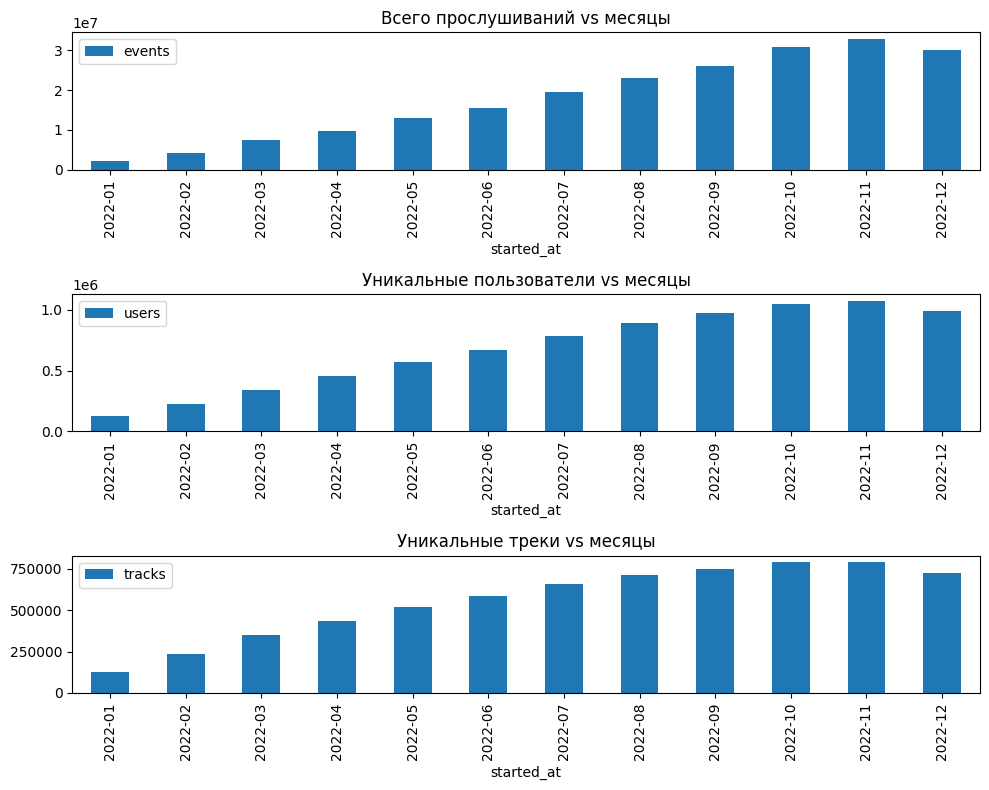

In [3]:
interactions_by_month = interactions.groupby(interactions['started_at'].dt.to_period('M')).agg(events=('started_at', 'count'), users=('user_id', 'nunique'), tracks=('track_id', 'nunique')).reset_index()

fig, ax = plt.subplots(3, 1, figsize=(10, 8))
interactions_by_month.plot('started_at', 'events', kind='bar', title='Всего прослушиваний vs месяцы', ax=ax[0])
interactions_by_month.plot('started_at', 'users', kind='bar', title='Уникальные пользователи vs месяцы', ax=ax[1])
interactions_by_month.plot('started_at', 'tracks', kind='bar', title='Уникальные треки vs месяцы', ax=ax[2])
fig.tight_layout()

interactions_by_month

### Распределение по пользователям
- сколько в среднем пользователь прослушал треков


In [4]:
interactions_by_user = interactions[['track_id', 'user_id']].groupby('user_id').agg(track_count=('track_id', 'count')).sort_values(by='track_count', ascending=False).reset_index()
interactions_by_user

,user_id,track_count
0,398979,16609
1,1200889,14371
2,590868,12700
3,731216,12508
4,339714,12103
...,...,...
1372037,1074759,1
1372038,1026515,1
1372039,489299,1
1372040,1104879,1


In [5]:
# посмотрим квантили распределения 
interactions_by_user['track_count'].describe().astype(int)

# среднее = 156
# min = 1
# 25Q = 22
# медиана = 54
# 75Q = 149
# max = 16609

count    1372042
mean         156
std          335
min            1
25%           22
50%           54
75%          149
max        16609
Name: track_count, dtype: int64

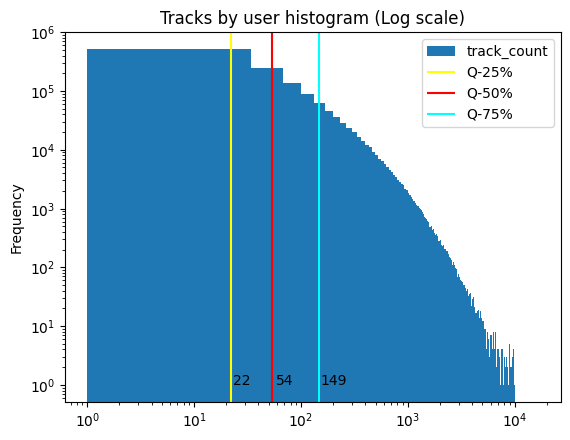

In [6]:
import numpy as np 

ax = interactions_by_user['track_count'].plot.hist(loglog=True, bins=500, legend=True, title='Tracks by user histogram (Log scale)')
plt.vlines([22], colors='yellow', ymin=0, ymax=1e6, label='Q-25%', )
plt.text(22 + 1, 1, '22')
plt.vlines([54], colors='red', ymin=0, ymax=1e6, label='Q-50%')
plt.text(54 + 5, 1, '54')
plt.vlines([149], colors='cyan', ymin=0, ymax=1e6, label='Q-75%')
plt.text(149 + 5, 1, '149')

ax.legend()

### Выводы
- количество пользователей и треков возрастают со временем, сервис набирает популярность, в декабре наметился небольшой спад
- распределение количества прослушанных треков пользователем
    - среднее = 156
    - медиана = 54
    - мин = 1
    - макс = 16609
    - после Q75% = 149 треков количество пользователей логарифмически убывает, и количество треков логарифмически растет

## Распределение треков по жанрам
- рассмотрим на какие жанры распределяются треки

In [7]:
path = 'data/preprocess/'
tracks_flat = pd.read_parquet(path + "tracks_flat.parquet")

<Axes: title={'center': 'Tracks distribution by genres'}, xlabel='genre_name'>

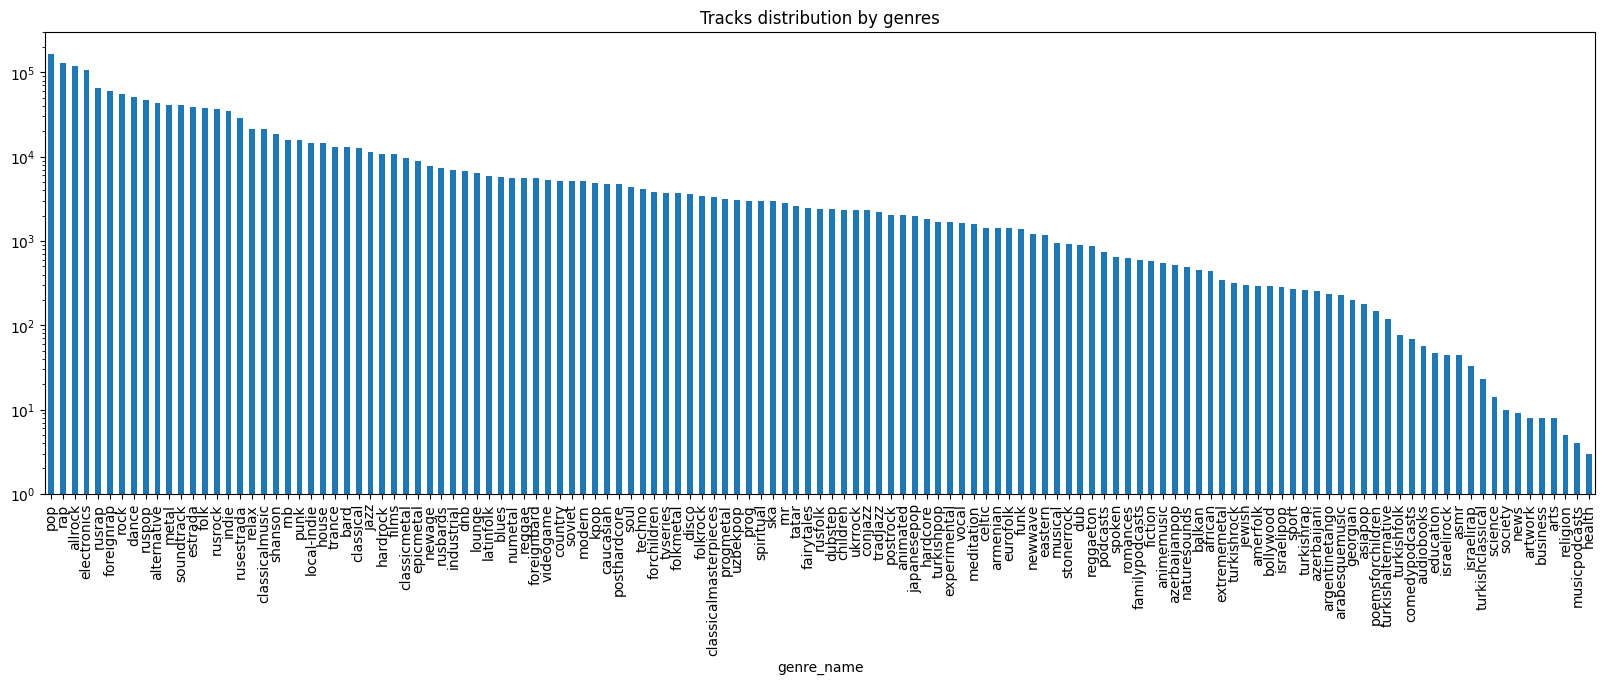

In [8]:
tracks_flat[['track_id', 'genre_name']].drop_duplicates() \
    .groupby('genre_name')['track_id'].count().rename('count').sort_values(ascending=False) \
    .plot.bar(log=True, rot=90, figsize=(20,6), title='Tracks distribution by genres')

## Распределение количества жанров по трекам
- рассмотрим скольк жанров приходится на один трек

In [9]:
genre_count = tracks_flat_combined['genre_id'].transform(len).rename('genre_count').value_counts().reset_index()
genre_count['ratio'] = genre_count['count'].transform(lambda x: x/genre_count['count'].sum())
genre_count

,genre_count,count,ratio
0,2,533253,0.571753
1,1,377274,0.404512
2,3,19511,0.020920
3,4,2190,0.002348
4,5,343,0.000368
5,6,39,0.000042
6,8,24,0.000026
7,7,16,0.000017
8,10,10,0.000011
9,9,4,0.000004


<Axes: title={'center': 'Genres amount by track distribution (logscale)'}, ylabel='Frequency'>

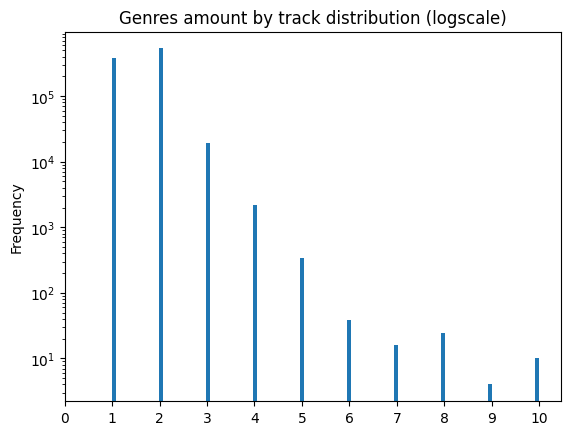

In [10]:
tracks_flat_combined['genre_id'].transform(len).plot.hist(bins=100, log=True, xticks=range(11), title='Genres amount by track distribution (logscale)')

### Вывод
- у большинства треков 1 (57%) или 2 (40%) жанра - в сумме 97% всех треков
    - еще у 2% 3 жанра
    - и оставшийся 1% распределяется на 4-10 жанров
- так как жанров всего 131 то матрица распределения треков по жанрам будет заполнять 1-2 ячейки, то есть ультра разреженная

## Наиболее популярные треки

- популярность определяем по частности взаимодействия (поскольку данных о рейтингах нет)

In [11]:
tracks_polularity = pd.DataFrame(interactions['track_id'].value_counts().sort_values(ascending=False)) \
    .merge(
        tracks_flat_combined.set_index('track_id'),
        on='track_id',
        how='left'
    ) \
    .reset_index()

tracks_polularity

,track_id,count,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,53404,111062,Smells Like Teen Spirit,"[4367, 89708, 294911, 294912, 294914, 297393, ...",[9262],"[13, 14, 102]","[Nevermind, Nirvana, Skiing Music, Smells Like...",[Nirvana],"[alternative, rock, allrock]"
1,33311009,106921,Believer,"[4440454, 4456609, 4482682, 4882996, 5072976, ...",[675068],"[14, 102]","[Shape Of Pop, NOW That's What I Call Music, E...",[Imagine Dragons],"[rock, allrock]"
2,178529,101924,Numb,"[18113, 21924, 21940, 488052, 10009799]",[36800],"[41, 47]","[Meteora, 00s Rock Anthems]",[Linkin Park],"[numetal, metal]"
3,35505245,99490,I Got Love,"[4431303, 20559909]","[4611844, 588511]","[3, 75]",[I Got Love],"[Miyagi & Эндшпиль, Рем Дигга]","[rusrap, rap]"
4,65851540,86670,Юность,[10692414],[1554548],"[11, 20]",[Юность],[Dabro],"[pop, ruspop]"
...,...,...,...,...,...,...,...,...,...
932659,22908851,5,Ирина и Марина,[2633273],"[3652834, 3652835]",[50],[Акустика],"[Константин Ступин, Ночная трость]",[punk]
932660,26554967,5,"Верка, Надька и Любка",[3162278],[42581],"[2, 102]",[IV],[Александр Башлачёв],"[rusrock, allrock]"
932661,28518742,5,На всём белом свете,[3412070],[503239],"[2, 102]",[Люди с чистой совестью],[Красные Звёзды],"[rusrock, allrock]"
932662,32507842,5,Солнцеворот,[3962826],[4747339],"[2, 102]",[Жёлтые песни],[Владимир Бурдин],"[rusrock, allrock]"


In [12]:
tracks_polularity[['count']].describe().astype(int)

,count
count,932664
mean,230
std,1404
min,5
25%,9
50%,19
75%,69
max,111062


### График топ-100 треков

<Axes: title={'center': 'Tracks poularity'}, xlabel='index,track_name'>

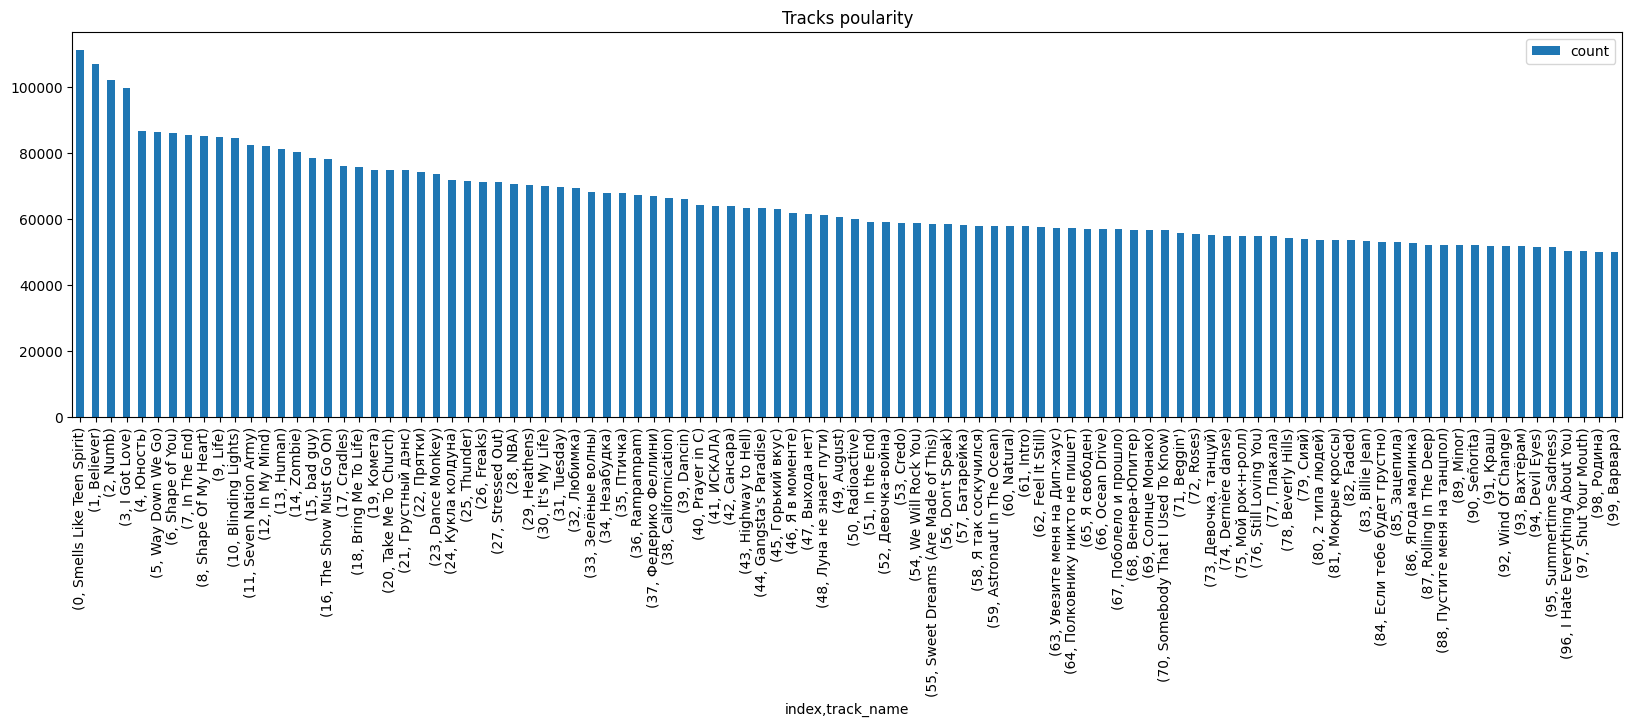

In [13]:
tracks_polularity[['track_name', 'count']] \
    .head(100) \
    .reset_index() \
    .set_index(['index', 'track_name']) \
    .plot.bar(legend=True, title='Tracks poularity', figsize=(20,5))

### Выводы
- популярность треков убывает линейным образом от лидеров к менее популярным
    - среднее - 230
    - мин - 5
    - медиана - 19
    - макс - 111062

## Наиболее популярные жанры

#### Общий список жанров

In [14]:
# список жанров из каталога
genres = catalog.query('type == "genre"').reset_index(drop=True)
genres

,id,type,name
0,0,genre,all
1,1,genre,eastern
2,2,genre,rusrock
3,3,genre,rusrap
4,4,genre,postrock
...,...,...,...
161,1182,genre,balkan
162,1197,genre,experimental
163,1370,genre,europop
164,1484,genre,meditation


In [15]:
# сохраним в файл на будущее
data_path = 'data/preprocess/'
genres.to_parquet(data_path + "genres.parquet")

#### Популярность жанров по истории взаимодействия
- будем определять популярность жанров, исходя из взаимодействий с треками - наиболее часто встречающиеся жанры по всем взаимодействиям со всеми треками (а не топ-треков)

In [16]:
genres_popularity = pd.DataFrame(interactions['track_id'].value_counts().sort_values(ascending=False).reset_index()) \
    .merge(
        tracks_flat_combined.set_index('track_id')[['genre_id', 'genre_name']],
        on='track_id',
        how='left'
    ) \
    .explode(['genre_id', 'genre_name'])  \
    .groupby(['genre_id', 'genre_name']).agg(count=('count', 'sum')).sort_values(by='count', ascending=False) \
    .reset_index()       

genres_popularity

,genre_id,genre_name,count
0,11,pop,55551134
1,75,rap,37799684
2,102,allrock,31085569
3,20,ruspop,26626234
4,3,rusrap,25303695
...,...,...,...
126,123,artwork,204
127,85,news,166
128,90,society,120
129,87,religion,73


##### График популярности жанров

<Axes: title={'center': 'Genres popularity (logscale)'}, xlabel='index,genre_name'>

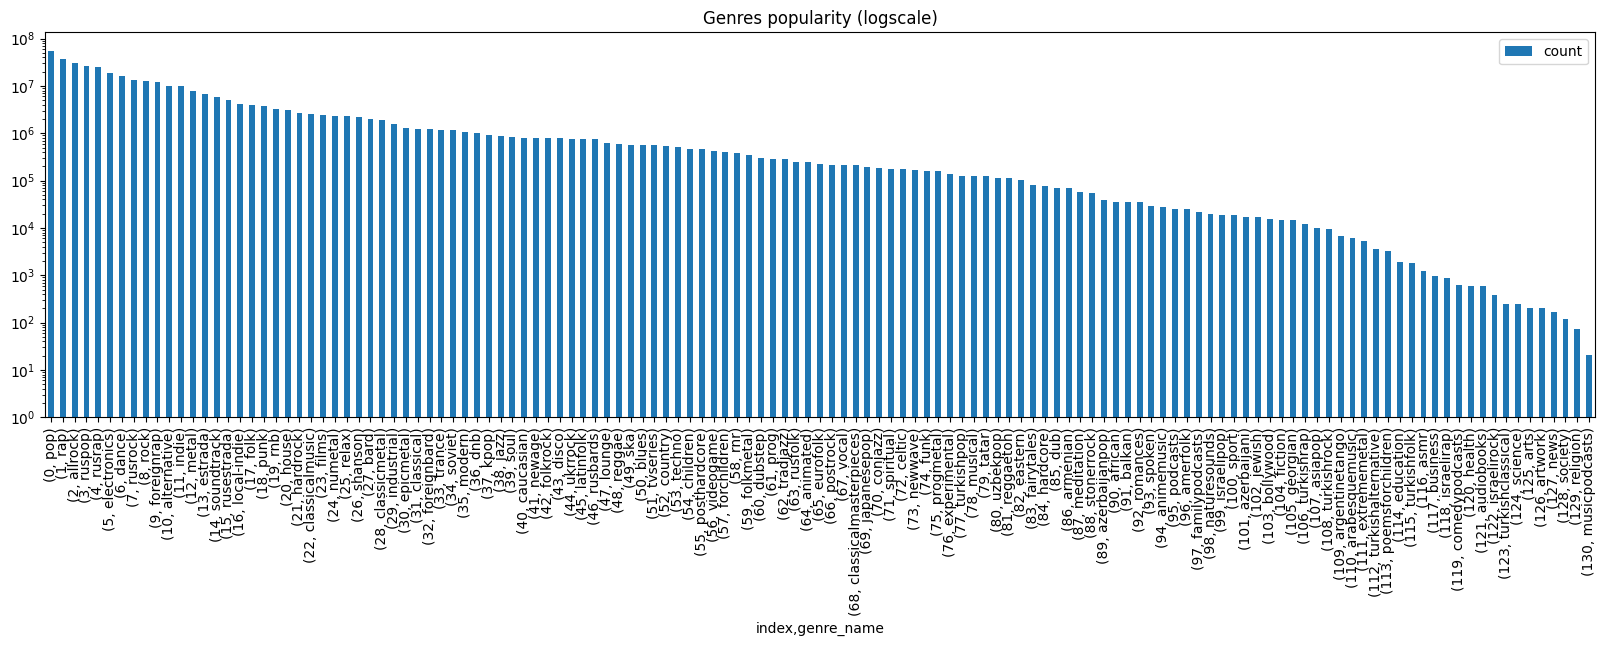

In [17]:
genres_popularity.reset_index()[['index', 'genre_name', 'count']].set_index(['index', 'genre_name']) \
    .plot.bar(log=True, title='Genres popularity (logscale)', figsize=(20,5))

### Непопулярные жанры
Рассмотрим жанры, которые вообще не попали в активность - то есть "непопулярны"

In [18]:
genres_not_popular = genres[~genres['id'].isin(genres_popularity['genre_id'])].reindex().reset_index(drop=True)
print(f'genres not popular (not in history) count = {genres_not_popular.shape[0]}')

genres_not_popular

genres not popular (not in history) count = 35


,id,type,name
0,0,genre,all
1,34,genre,caribbean
2,36,genre,classic
3,42,genre,holiday
4,46,genre,latin
5,78,genre,hobbies
6,81,genre,technology
7,82,genre,government
8,83,genre,historypodcasts
9,91,genre,recreation


In [19]:
tracks_flat_combined[tracks_flat_combined['genre_id'].isin(genres_not_popular['id'])]

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name


### Вывод 
- топ-3 жанра
    - pop
    - rap
    - allrock
- видно что есть 35 жанров, по которым нет истории взаимодействия
    - но и треков с этими жанрами нет

## Треки, которые никто не прослушал

In [20]:
tracks_no_activity = tracks_flat_combined[~tracks_flat_combined['track_id'].isin(tracks_polularity['track_id'])]
tracks_no_activity

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name


### Выводы
- треков, которые никто не прослушал, нет

Комментарий ревьюера ✔️
Вопросов нет, отличный EDA, отличная визуализация, отличные решения.

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [21]:
# tracks_flat_combined - содержит всю необходимую информацию в удобном виде
# переименуем track_id в item_id для унификации, и приведем к int32 для сокращения памяти

tracks_flat_combined.rename(columns={'track_id': 'item_id'}, inplace=True)
tracks_flat_combined['item_id'] = tracks_flat_combined['item_id'].astype('int32')
tracks_flat_combined

,item_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


In [22]:
tracks_flat_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 932664 entries, 0 to 932663
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   item_id      932664 non-null  int32 
 1   track_name   932664 non-null  object
 2   album_id     932664 non-null  object
 3   artist_id    932664 non-null  object
 4   genre_id     932664 non-null  object
 5   album_name   932664 non-null  object
 6   artist_name  932664 non-null  object
 7   genre_name   932664 non-null  object
dtypes: int32(1), object(7)
memory usage: 53.4+ MB


In [23]:
# переименуем track_id в item_id для унификации

interactions.rename(columns={'track_id': 'item_id'}, inplace=True)
interactions

,user_id,item_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


In [24]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214720738 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   item_id     int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.2 GB


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [25]:
# сначала сохраним локально 
path = 'data/recsys/'

tracks_flat_combined.sort_values(by='item_id', ignore_index=True).to_parquet(path + "items.parquet")
interactions.sort_values(by=['user_id','started_at'], ignore_index=True).to_parquet(path + "events.parquet")

In [26]:
# проверка файлов для отправки в S3

import pandas as pd

path = 'data/recsys/'
items = pd.read_parquet(path + "items.parquet")
events = pd.read_parquet(path + "events.parquet")

Сохранение в S3-хранилище

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

# pip install s3fs

# теперь сохраним в S3

s3_storage = os.getenv('S3_ENDPOINT_URL')           # https://storage.yandexcloud.net
s3_bucket = os.getenv('S3_BUCKET_NAME')             # s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4
s3_access_key = os.getenv('AWS_ACCESS_KEY_ID')      # YCAJE3Nlz8iDILW5VTYM1ihQB
s3_secret_key = os.getenv('AWS_SECRET_ACCESS_KEY')  # secret

path = "s3://" + s3_bucket + "/recsys/data/"
print(path)

# параметры подключения к S3 хранилищу
storage_options = {
    "client_kwargs": {"endpoint_url": s3_storage},
    "key": s3_access_key,  
    "secret": s3_secret_key,  
}

items.to_parquet(path + "items.parquet", storage_options=storage_options)
events.to_parquet(path + "events.parquet", storage_options=storage_options)

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [105]:
# 1 - промежуточные файлы сохранены в data/preprocess 
#   - так что для EDA-анализа по этапу 2 можно загрузить файлы в начале секции "Этапа 2" 
#   - и повторить любой из этапов без необходимости выполнения исходной последовательности

# 2 - все рабочие файлы для создания рекомендательной системы сохранены в 
#   - локально - data/recsys 
#   - в S3 - https://storage.yandexcloud.net/s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4/recsys/data/

# - Этап 3 надо начинать с чистого листа и kerner restart

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet 
!!! для разных этапов может потребоваться раскоментировать конкретные строчки для их выполнения - это не статичный раздел

In [1]:
# проверка файлов для отправки в S3

import pandas as pd

path = 'data/recsys/'

items = pd.read_parquet(path + "items.parquet")
events = pd.read_parquet(path + "events.parquet")

#--- т.к. даже 32 Gb памяти на ВМ не хватает для полного прогона формирования персональных ALS рекомендаций, то потребуется начинать с промежутончых этапов

# промежуточные результаты, для выполнения разных этапов подготовки - нужно раскрыть нужные комментарии для точечных задач
#events_train = pd.read_parquet(path + 'events_train.parquet')


In [2]:
items

,item_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


In [3]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 932664 entries, 0 to 932663
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   item_id      932664 non-null  int32 
 1   track_name   932664 non-null  object
 2   album_id     932664 non-null  object
 3   artist_id    932664 non-null  object
 4   genre_id     932664 non-null  object
 5   album_name   932664 non-null  object
 6   artist_name  932664 non-null  object
 7   genre_name   932664 non-null  object
dtypes: int32(1), object(7)
memory usage: 53.4+ MB


In [4]:
events

,user_id,item_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
214720733,1374582,95514767,288,2022-12-29
214720734,1374582,97220301,289,2022-12-29
214720735,1374582,97241171,290,2022-12-29
214720736,1374582,98542641,291,2022-12-29


In [5]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214720738 entries, 0 to 214720737
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   item_id     int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 3.6 GB


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [6]:
train_date_split = '2022-12-16'
events_train = events.query('started_at < @train_date_split').copy()
events_test = events.query('started_at >= @train_date_split').copy()

print(f'events_train size: {events_train.shape[0]:,} ({(100*events_train.shape[0]/events.shape[0]):.2f}%), events_test size: {events_test.shape[0]:,} ({(100*events_test.shape[0]/events.shape[0]):.2f}%)')

events_train size: 201,204,460 (93.71%), events_test size: 13,516,278 (6.29%)


# Топ популярных

Рассчитаем рекомендации как топ популярных, рассчитанных на этапе 2 EDA - "Наиболее популярные треки" и сохраненные в соответсвующий файл

In [7]:
tracks_polularity = pd.DataFrame(events_train[['item_id']].value_counts().sort_values(ascending=False))
tracks_polularity

,count
item_id,
53404,110026
33311009,101076
178529,100866
35505245,95523
24692821,84153
...,...
99697367,1
99716115,1
88176782,1


## Сохраним топ-100 треков в top_popular.parquet

In [8]:
path = 'data/recsys/'
top_n = 100
tracks_polularity.head(top_n).to_parquet(path + 'top_popular.parquet')

# Персональные

Рассчитаем персональные рекомендации.

## Закодируем идентификторы объектов для подготовки csr-матрицы

In [9]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
user_encoder.fit(events.user_id)

item_encoder = LabelEncoder()
item_encoder.fit(events.item_id)

LabelEncoder()

Сохраним кодировщики в файл, для будущего переиспользования и экономии памяти на последующих этапах

In [10]:
import joblib

path = 'data/recsys/'
joblib.dump(user_encoder, path + 'user_encoder.joblib')
joblib.dump(item_encoder, path + 'item_encoder.joblib')

['data/recsys/item_encoder.joblib']

Загрузка из файлов при необходимости на нужном этапе

In [3]:
import joblib

path = 'data/recsys/'
user_encoder = joblib.load(path + 'user_encoder.joblib')
item_encoder = joblib.load(path + 'item_encoder.joblib')

In [12]:
events_train['user_id_enc'] = user_encoder.transform(events_train.user_id)
events_train['item_id_enc'] = item_encoder.transform(events_train.item_id)

# сократим потребление памяти с int64 на int32
events_train = events_train.astype({'user_id_enc': 'int32', 'item_id_enc': 'int32'})

Комментарий ревьюера ✔️
Очень хорошо!

Выполним промежуточное сохранение events_train с закодированными идентификаторами в файл

In [13]:
path = 'data/recsys/'
events_train.to_parquet(path + 'events_train.parquet')

Подготовим также данные для events_test

In [14]:
events_test['user_id_enc'] = user_encoder.transform(events_test.user_id)
events_test['item_id_enc'] = item_encoder.transform(events_test.item_id)
events_test = events_test.astype({'user_id_enc': 'int32', 'item_id_enc': 'int32'})

Выполним промежуточное сохранение events_test с закодированными идентификаторами в файл

In [15]:
path = 'data/recsys/'
events_test.to_parquet(path + 'events_test.parquet')

In [16]:
# пока не нужны, можно почистить
del events
del events_test

Комментарий ревьюера ⚠️
Память может не освободиться сразу из-за ссылок в других объектах. После del вызываем gc.collect().

## Сформируем матрицу взаимодействия user-2-item

In [17]:
from scipy.sparse import csr_matrix
import numpy as np

user2item_matrix_train = csr_matrix(
    (np.ones(events_train.shape[0], dtype=np.int8),
    (events_train.user_id_enc.values, events_train.item_id_enc.values))
)
user2item_matrix_train

<Compressed Sparse Row sparse matrix of dtype 'int8'
	with 201204460 stored elements and shape (1372042, 932664)>

## Обучим ALS-модель

In [ ]:
%env OPENBLAS_NUM_THREADS=1

from implicit.als import AlternatingLeastSquares

n_factors = 50
n_iterations = 15
model_als = AlternatingLeastSquares(factors=n_factors, iterations=n_iterations, regularization=0.05, random_state=15)
model_als.fit(user2item_matrix_train)

### Сохраним обученную модель в файл
- сэкономим 12 минут при повторных операциях

In [13]:
path = 'data/recsys/'
model_als.save(path + 'model_als_trained.npz')

### Загрузим обученную модель из файла 

In [19]:
%env OPENBLAS_NUM_THREADS=1

from implicit.als import AlternatingLeastSquares

path = 'data/recsys/'

# this not works - got empty factors after load()
#   n_factors = 50
#   n_iterations = 15
#   model_als = AlternatingLeastSquares(factors=n_factors, iterations=n_iterations, regularization=0.05, random_state=15)
#   model_als.load(path + 'model_als_trained.npz')

# this works
model_als = AlternatingLeastSquares().load(path + 'model_als_trained.npz')


env: OPENBLAS_NUM_THREADS=1


/home/mle-user/mle_projects/sprint-4/mle-project-sprint-4-v001/.venv_mle-project-sprint-4-v001/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/sprint-4/mle-project-sprint-4-v001/.venv_mle-project-sprint-4-v001/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


## Сформируем персональные топ-100 рекомендации для всех пользователей

In [21]:
# clear as much memory as we can

#del events
#del events_train

In [17]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(len(user_encoder.classes_))

# получаем рекомендации для всех пользователей
als_recommendations_raw = model_als.recommend(
    user_ids_encoded, 
    user2item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, 
    N=100)

item_ids_enc = als_recommendations_raw[0]
scores_als = als_recommendations_raw[1]

### Сохраним в файл сырые данные рекомендаций
- 46 минут генерации

In [18]:
import numpy as np

path = 'data/recsys/'
np.savez_compressed(path + 'als_recommendations_raw.npz', item_ids=item_ids_enc, scores=scores_als)

### Загрузка готовых сырых рекомендаций из файла

может потребоваться kernel restart и перечитка переменных из соответсветсвующих разделов (например user_encoder)

In [1]:
import numpy as np

path = 'data/recsys/'

loaded_recs = np.load(path + 'als_recommendations_raw.npz')
item_ids_enc = loaded_recs['item_ids']
scores_als = loaded_recs['scores']

## Сформируем рекомендации в удобном табличном формате

In [4]:
import pandas as pd

# преобразуем полученные рекомендации в табличный формат (~15Gb memory required)

user_ids_encoded = range(len(user_encoder.classes_))

als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": scores_als.tolist()})
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])

als_recommendations

,score,user_id,item_id
0,0.014193,0,597196
1,0.012967,0,29213451
2,0.012012,0,27077792
3,0.010728,0,19722850
4,0.010566,0,21101463
...,...,...,...
137204195,0.095507,1374582,48591588
137204196,0.095246,1374582,33308971
137204197,0.094276,1374582,72340123
137204198,0.094246,1374582,68106316


## Сохраним полученные рекомендации в файл

In [21]:
als_recommendations = als_recommendations[["user_id", "item_id", "score"]]

path = 'data/recsys/'
als_recommendations.to_parquet(path + "personal_als.parquet")

можно выполнить kernel restart

## Проверим визуально как формируются персональные рекомендации

In [1]:
import pandas as pd

path = 'data/recsys/'
als_recommendations = pd.read_parquet(path + "personal_als.parquet")
events_train = pd.read_parquet(path + "events_train.parquet")
items = pd.read_parquet(path + "items.parquet")

Инициализировать кодировщики вручную из соответсвующей секции, чтобы не дублировать сюда

In [4]:
import numpy as np

uid_enc = np.random.randint(0, 1000000)
uid = user_encoder.inverse_transform([uid_enc])[0]

print(f'pesonal history for user id = {uid} (10 recent tracks):')
user_history = events_train[events_train['user_id'] == uid] \
    .merge(items, on='item_id')

display(user_history.tail(10))

personal_recs = als_recommendations.query('user_id == @uid') \
    .merge(items, on='item_id')

print('pesonal recomendations (top 10):')
display(personal_recs.head(10))

pesonal history for user id = 156881 (10 recent tracks):


,user_id,item_id,track_seq,started_at,user_id_enc,item_id_enc,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
3894,156881,85996059,3984,2022-12-15,156604,888472,I Like To Party,[16474398],[7290183],[13],[I Like To Party],[Jagwar Twin],[alternative]
3895,156881,86052132,3985,2022-12-15,156604,888779,Поиграем,[16492171],[5809288],"[11, 20]",[Поиграем],[ФРЕНДЗОНА],"[pop, ruspop]"
3896,156881,86052167,3986,2022-12-15,156604,888783,"каждый, кто делал тебе больно",[16492194],[10983287],"[6, 70]","[каждый, кто делал тебе больно]","[забей, лерочка]","[local-indie, indie]"
3897,156881,86248466,3988,2022-12-15,156604,889409,4 шота,[16554671],[8739954],"[11, 20]",[Княжна из хрущёвки],[DEAD BLONDE],"[pop, ruspop]"
3898,156881,86299284,3989,2022-12-15,156604,889604,Куда уходит детство,[16565453],[6826935],"[6, 70]",[Куда уходит детство],[Дора],"[local-indie, indie]"
3899,156881,86321562,3990,2022-12-15,156604,889641,Head Up,"[16571160, 17858268, 21215586]",[595142],[13],"[Head Up, Chrysalis, Metamorph]",[The Score],[alternative]
3900,156881,86416030,3991,2022-12-15,156604,889865,Wrecked,"[16601101, 16972741, 17219479, 17846057, 18300...",[675068],"[14, 102]","[Wrecked, Estate 2021 Hits Italia, ESTATE 202...",[Imagine Dragons],"[rock, allrock]"
3901,156881,86446784,3992,2022-12-15,156604,890086,Пора бы улыбаться,[16611915],[1556385],"[11, 20]",[ЖИЗА],[HENSY],"[pop, ruspop]"
3902,156881,86576034,3993,2022-12-15,156604,890572,Ночи горят огнём,[16655411],[6467364],"[11, 20]",[Ночи горят огнём],[NЮ],"[pop, ruspop]"
3903,156881,86610665,3994,2022-12-15,156604,890786,Лаллипап,[16666940],[6019372],"[11, 20]",[Лаллипап],[МЭЙБИ БЭЙБИ],"[pop, ruspop]"


pesonal recomendations (top 10):


,user_id,item_id,score,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,156881,57185718,1.519415,Молчи,[8570211],[6502292],[50],[Магазин игрушек для взрослых],[кис-кис],[punk]
1,156881,35338498,1.472798,Самый дорогой человек,"[4398954, 16409235]",[428038],"[5, 102]","[Самый дорогой. Часть 1, Navigator Records 15]",[Нервы],"[ukrrock, allrock]"
2,156881,3703085,1.387981,Radioactive,"[414324, 587845, 951692, 1061748, 1597165, 189...",[675068],"[13, 14, 17, 25, 102]","[Continued Silence EP, Night Visions, The Host...",[Imagine Dragons],"[alternative, rock, films, soundtrack, allrock]"
3,156881,17079396,1.384927,Take Me To Church,"[1877668, 2256751, 2256752, 3060154, 10108521,...",[1401151],[70],"[Take Me To Church, Hozier, Лучшие хиты: Альте...",[Hozier],[indie]
4,156881,23559960,1.384539,Stressed Out,"[2719136, 2747498, 3361936, 3523463, 3600798, ...",[792433],[70],"[Stressed Out, Blurryface, Spring Music 2016, ...",[twenty one pilots],[indie]
5,156881,29611476,1.358349,Heathens,"[3563259, 3656951, 3656952, 3786806, 5933975]",[792433],"[17, 25]","[Heathens, Suicide Squad: The Album, Pop]",[twenty one pilots],"[films, soundtrack]"
6,156881,9060176,1.353385,Sweater Weather,"[951105, 1107491, 21150967, 21151002]",[105648],[70],"[I'm Sorry..., I Love You., Simping Songs, Lov...",[The Neighbourhood],[indie]
7,156881,33311009,1.324676,Believer,"[4440454, 4456609, 4482682, 4882996, 5072976, ...",[675068],"[14, 102]","[Shape Of Pop, NOW That's What I Call Music, E...",[Imagine Dragons],"[rock, allrock]"
8,156881,3703081,1.284167,Demons,"[414324, 587845, 951692, 1597165, 2405344, 609...",[675068],"[13, 14, 102]","[Continued Silence EP, Night Visions, Top Musi...",[Imagine Dragons],"[alternative, rock, allrock]"
9,156881,19152669,1.278247,Centuries,"[2146721, 2454211, 3232399, 3861128, 4645119, ...",[5976],[13],"[Centuries, American Beauty/American Psycho, K...",[Fall Out Boy],[alternative]


трудно сказать .. но вроде есть схожесть 

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

## Используем обученную сохраненную ALS-модель для получения похожих объектов

Загрузка модели

In [ ]:
from implicit.als import AlternatingLeastSquares

path = 'data/recsys/'
model_als = AlternatingLeastSquares().load(path + 'model_als_trained.npz')

## Получение 10 похожих объектов для всех объектов

In [7]:
item_ids_encoded = range(len(item_encoder.classes_))

sim_item_ids_enc, sim_scores_als = model_als.similar_items(itemid=item_ids_encoded, N=10)

Сохраним сырые результаты в файл, чтобы не обучать постоянно повторно (> 41 min)

In [8]:
path = 'data/recsys/'
np.savez_compressed(path + 'sim_als_recommendations_raw.npz', item_ids=sim_item_ids_enc, scores=sim_scores_als)

Восстановление из файла

In [5]:
import numpy as np

path = 'data/recsys/'

loaded_recs = np.load(path + 'sim_als_recommendations_raw.npz')
sim_item_ids_enc = loaded_recs['item_ids']
sim_scores_als = loaded_recs['scores']

## Приведем к удобной табличной форме

In [6]:
import pandas as pd

# преобразуем полученные рекомендации в табличный формат (~15Gb memory required)

item_ids_encoded = range(len(item_encoder.classes_))

sim_recs_als = pd.DataFrame({
    "item_id_enc": item_ids_encoded,
    "sim_item_id_enc": sim_item_ids_enc.tolist(), 
    "score": sim_scores_als.tolist()})
sim_recs_als = sim_recs_als \
    .explode(["sim_item_id_enc", "score"], ignore_index=True) \
    .astype({
        'item_id_enc': 'int32',
        'sim_item_id_enc': 'int32',
        'score': 'float32'
    })

# получаем изначальные идентификаторы
sim_recs_als["item_id"] = item_encoder.inverse_transform(sim_recs_als["item_id_enc"])
sim_recs_als["sim_item_id"] = item_encoder.inverse_transform(sim_recs_als["sim_item_id_enc"])

sim_recs_als = sim_recs_als.drop(columns=["item_id_enc", "sim_item_id_enc"])

sim_recs_als

,score,item_id,sim_item_id
0,1.000000,26,26
1,0.841317,26,20111365
2,0.826416,26,27419607
3,0.820421,26,26343802
4,0.803062,26,1293112
...,...,...,...
9326635,0.849149,101521819,92503045
9326636,0.848006,101521819,97820398
9326637,0.844078,101521819,101084646
9326638,0.837228,101521819,94735558


## Сохраним похожие объекты в файл similar.parquet

In [13]:
path = 'data/recsys/'
sim_recs_als = sim_recs_als[["item_id", "sim_item_id", "score"]]
sim_recs_als.to_parquet(path + 'similar.parquet')

Восстановление из файла

In [14]:
import pandas as pd

path = 'data/recsys/'
sim_recs_als = pd.read_parquet(path + 'similar.parquet')

## Проверим визуально как формируются похожие объекты

In [7]:
items = pd.read_parquet(path + "items.parquet")

In [8]:
track_name = 'We are the champions' 
artist_name = 'Queen' 

target_track = items[
    items['track_name'].str.contains(track_name, case=False) 
    &
    items['artist_name'].str.join(',').str.contains(artist_name, case=False)
    ].head(1)

target_track

,item_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
41107,377099,We Are The Champions,"[33024, 38522]",[79215],"[14, 102]","[Absolute Greatest, News Of The World]",[Queen],"[rock, allrock]"


In [9]:
target_item_id = target_track['item_id'].iat[0]
print(f'target for item id = {target_item_id}')
display(target_track)

sim_recs = sim_recs_als[sim_recs_als['item_id'] == target_item_id] \
    .merge(items, left_on='sim_item_id', right_on='item_id')

print('similar items')
display(sim_recs)


target for item id = 377099


,item_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
41107,377099,We Are The Champions,"[33024, 38522]",[79215],"[14, 102]","[Absolute Greatest, News Of The World]",[Queen],"[rock, allrock]"


similar items


,score,item_id_x,sim_item_id,item_id_y,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,1.000000,377099,377099,377099,We Are The Champions,"[33024, 38522]",[79215],"[14, 102]","[Absolute Greatest, News Of The World]",[Queen],"[rock, allrock]"
1,0.778711,377099,16548495,16548495,I Wanna Be Loved By You,[1812107],[53887],[25],[I Wanna Be Loved By You],[Marilyn Monroe],[soundtrack]
2,0.758943,377099,4561322,4561322,First in Line,[513795],[10987],"[102, 415]",[The Original Masters and the Outtakes],[Elvis Presley],"[allrock, rnr]"
3,0.749597,377099,2616288,2616288,Swanee River Rock,"[271209, 849160, 3447037]",[443],"[28, 33, 923]","[Yes Indeed, A Genius At His Best, Vol.10, The...",[Ray Charles],"[jazz, blues, tradjazz]"
4,0.747585,377099,8924869,8924869,Winter Wonderland,"[933724, 2305057, 2311245, 2403666, 2445519]",[3989],[28],"[Merry Christmas from the Crooners, Best of Ja...",[Frank Sinatra],[jazz]
5,0.738137,377099,103048,103048,Ben,"[9661, 9957]",[972],[11],[Pure Michael: Motown A Cappella],[Michael Jackson],[pop]
6,0.735225,377099,1314515,1314515,Stand By Me,[138520],[2091],[74],[Stand By Me],[Ben E. King],[rnb]
7,0.734561,377099,10822,10822,Sunny,"[1054, 5788254, 11345811, 12037758]",[978],"[26, 74]","[Soul Legends - Marvin Gaye, Essential Motown ...",[Marvin Gaye],"[soul, rnb]"
8,0.733855,377099,5285345,5285345,Dream a Little Dream,[581972],[2678],"[28, 923]",[Ella Fitzgerald],[Ella Fitzgerald],"[jazz, tradjazz]"
9,0.732550,377099,15536916,15536916,I Can't Stop Loving You,[1696604],[443],[74],[Ray Charles Collection Supreme],[Ray Charles],[rnb]


Работает - похожие треки выглядят неплохо .. Френк Синатра, Элвис Пресли ..

# Построение признаков

можно выполнить kernel restart

Построим три признака, можно больше, для ранжирующей модели.

Будем рассматривать следующие 5 признаков:
- признаки моделей-генераторов кандидатов
    - оценка (score) трека от персональных als-рекомендаций (коллаборативные рекомендации)
    - оценка похожести трека (score) по неявным жанровым предпочтениям пользователя, выявленным по его истории (контентные рекомендации)
- совместные признаки трека+пользователя
    - индекс популярности трека в общем рейтинге популярности треков
    - индекс популярности жанра в общем рейтинге жанров (1-ый жанр трека)
    - общее количество треков, которые прослушал пользователь

## 1. Оценка (score) трека от персональных als-рекомендаций 
- этот признак уже рассчитан ранее в als_recommendations

## 2. Оценка (score) похожести трека по неявным жанровым предпочтениям пользователя, выявленным по его истории (контентные рекомендации)
- такой признак и модель генерации еще не была ранее создана - реализуем этот механизм в рамках данного этапа
- для определения данного признака подготовим данные для расчета - фактически это будут рекомендации на основе контента (в отличие от коллаборативных рекомендаций ALS-модели)
    - матрицу трек-жанры (item-2-genre) - из каких жанров состоит трек
    - матрицу пользователь-жанры (user-2-genre) - какие жанры предпочитает пользователь по его прослушанным трекам
- для выбранного/предложенного трека вычислим степень похожести через косинусную близость между векторами трек-жанр и пользователь-жанр 
    - забегая вперед - за приемлемое время это сделать было невозможно, поэтому был изучен и использован механизм FAISS (Facebook AI Similarity Search)

Особенности
- в основном (97%) все треки имеют 1 или 2 жанра (см. раздел EDA - Распределение количества жанров по трекам)
    - поэтому похожесть по жанрам будет малоразличимой для разных треков - из-за огромного (сотни тысяч) треков с одинаковыми жанрами
    - это должно снизить эффективность прямого отбора похожих треков в лоб, но как дополнительный признак для ранжирования будет полезен

### Сформируем матрицу item-2-genre
- распределение каждого объекта по всем возможным жанрам
- по ней в дальнейшем будем искать схожие объекты по жанровым предчпочтениям пользователя

In [5]:
import pandas as pd
import joblib

path = 'data/recsys/'
items = pd.read_parquet(path + "items.parquet")

# загрузим кодировщик для объектов
item_encoder = joblib.load(path + 'item_encoder.joblib')

In [7]:
# идентификаторы жанров не сквозные, поэтому потребуется применить кодирование

from sklearn.preprocessing import LabelEncoder

genre_encoder = LabelEncoder()
genre_encoder.fit(items['genre_id'].explode())

print(f'genres count: {len(genre_encoder.classes_)}')

genres count: 131


In [8]:
# соберем разреженную матрицу item2genre

import numpy as np
from scipy.sparse import csr_matrix

item2genres = items[['item_id', 'genre_id']].explode('genre_id')
item2genres['genre_id_enc'] = genre_encoder.transform(item2genres['genre_id'])
item2genres['item_id_enc'] = item_encoder.transform(item2genres['item_id'])

item2genres_matrix_csr = csr_matrix(
    (np.ones(item2genres.shape[0], dtype=np.int32),
     (item2genres['item_id_enc'], item2genres['genre_id_enc']))
)

item2genres_matrix_csr

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 1513462 stored elements and shape (932664, 131)>

### Матрица - все жанры - genres

In [4]:
import pandas as pd
path = 'data/preprocess/'
genres = pd.read_parquet(path + "genres.parquet")
genres = genres[genres['id'].isin(genre_encoder.classes_)]
genres.shape

(131, 3)

### Матрица user-2-genre
- характеризуем жанровые предпочтения пользователя на основе его истории взаимодействия с объектами (треками)

In [8]:
import pandas as pd

path = 'data/recsys/'
events_train = pd.read_parquet(path + "events_train.parquet", columns=['user_id', 'item_id', 'item_id_enc'])

#### user-2-genres - сначала проверим как работает на одном пользователе (выборочном)

In [9]:
user_id = 100

def get_user2genre_matrix_csr(user_id, events_history, item2genres_matrix_csr):
    user_events = events_history[events_history['user_id'] == user_id][['user_id', 'item_id']]
    user_events['item_id_enc'] = item_encoder.transform(user_events['item_id'])

    user2genres_matrix_csr = item2genres_matrix_csr[user_events['item_id_enc']]

    user2genres_score = user2genres_matrix_csr.mean(axis=0)
    user2genres_score = np.ravel(user2genres_score)
    return user2genres_score.astype('float32')

user2genres_score = get_user2genre_matrix_csr(user_id, events_train, item2genres_matrix_csr)

print(user2genres_score.shape)
user2genres_score

(131,)


array([0.        , 0.00934579, 0.06542056, 0.        , 0.        ,
       0.00934579, 0.        , 0.        , 0.        , 0.        ,
       0.13084112, 0.        , 0.04672897, 0.03738318, 0.        ,
       0.03738318, 0.00934579, 0.        , 0.        , 0.04672897,
       0.        , 0.        , 0.        , 0.        , 0.01869159,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00934579, 0.        ,
       0.36448598, 0.        , 0.00934579, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00934579,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.19626169, 0.        ,
       0.01869159, 0.        , 0.        , 0.        , 0.04672897,
       0.43925235, 0.        , 0.        , 0.        , 0.     

Комментарий ревьюера ⚠️
Здесь можно использовать векторизованный подход.

Посмотрим какие жанры предпочтитает пользователь

,id,type,name,score
0,75,genre,rap,0.439252
1,44,genre,foreignrap,0.364486
2,68,genre,electronics,0.196262
3,11,genre,pop,0.130841
4,332,genre,dnb,0.084112
5,3,genre,rusrap,0.065421
6,102,genre,allrock,0.056075
7,20,genre,ruspop,0.046729
8,74,genre,rnb,0.046729
9,13,genre,alternative,0.046729


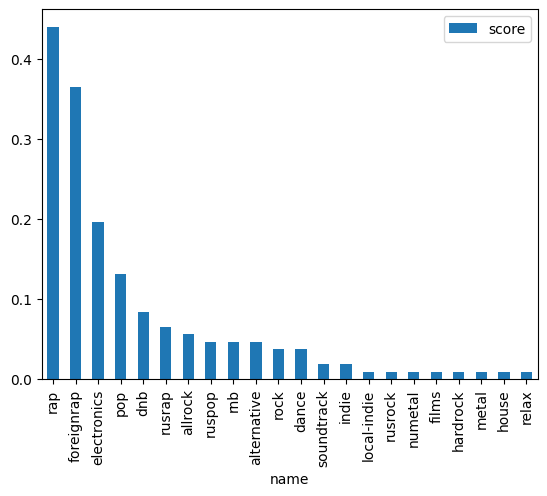

In [10]:
def show_user_genres(user2genres_score, genres, show_plot=True):
    user2genres = genres.copy()
    user2genres['score'] = user2genres_score
    user2genres = user2genres[user2genres['score'] > 0].sort_values(by='score', ascending=False).reset_index(drop=True)
    display(user2genres)
    
    if show_plot:
        user2genres.plot.bar(x='name', y='score')

show_user_genres(user2genres_score, genres)

#### top-100 рекомендации для пользователя
- проверим механику формирования топ-100 рекомендаций для одного пользователя
- на основе определения косинусного сходства вектора жанров пользователя и векторов жанров всех объектов

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

top_n = 100

similar_items_scores = cosine_similarity(X=item2genres_matrix_csr, Y=user2genres_score.reshape((1,131))).flatten()
top_n_item_indices = np.argsort(similar_items_scores)[-top_n:][::-1]

items[items['item_id'].isin(item_encoder.inverse_transform(top_n_item_indices))]

,item_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
14167,93759,Zumbie,"[8430, 8773, 16982970]","[34998, 714724]","[44, 68, 75]",[Guns Don't Kill People...Lazers Do],"[Major Lazer, Andy Milonakis]","[foreignrap, electronics, rap]"
22013,148403,What's the Altitude,"[14382, 16887, 18094, 38064]","[13901, 2055393]","[44, 68, 75]","[The Audience's Listening, The Audience Is Lis...","[Cut Chemist, Hymnal]","[foreignrap, electronics, rap]"
45937,448808,Planet Rock,"[46438, 740761, 1116414, 2291903, 4501503]","[13795, 1212902]","[44, 68, 75]","[Planet Rock / Planet Rock, Planet Rock, Plane...","[Afrika Bambaataa, The Soulsonic Force]","[foreignrap, electronics, rap]"
90247,906022,Invincible (feat. Kelly Rowland),"[103767, 194796, 432688]","[157799, 74614]","[44, 68, 75]","[Disc-Overy, Invincible (feat. Kelly Rowland)]","[Tinie Tempah, Kelly Rowland]","[foreignrap, electronics, rap]"
106998,2013693,Guitar,"[199185, 3764039]",[255284],"[44, 68, 75]",[Bust a Groove],[Paul Oakenfold],"[foreignrap, electronics, rap]"
...,...,...,...,...,...,...,...,...
893398,87378006,Guts,"[16882670, 17366089]","[1134604, 4647448]","[44, 75]","[Guts, FLOAT]","[K Camp, True Story Gee]","[foreignrap, rap]"
893399,87380447,Appreciation,[16883292],"[5957438, 632133, 1724834]","[44, 75]",[Appreciation],"[Ant Clemons, 2 Chainz, Ty Dolla $ign]","[foreignrap, rap]"
903767,90145009,Poison,"[17770391, 17772511, 17773628, 20783738, 20917...","[3874974, 3442415]","[44, 68, 75]","[Poison, DICHOTOMY]","[Slumberjack, Sydnee Carter]","[foreignrap, electronics, rap]"
926248,97400018,LA ESPADA,"[20061907, 21276061]",[6670303],"[44, 68, 75]","[LA ESPADA (slowed and reverbed), LA ESPADA]",[Eternal Raijin],"[foreignrap, electronics, rap]"


#### top-100 рекомендации для всех пользователей 
- теперь выполним генерацию топ-100 жанровых (контентных) рекомендаций для всей базы пользователей

In [12]:
user_events = events_train[['user_id', 'item_id_enc']].groupby('user_id').agg(item_ids_enc=('item_id_enc', list)).reset_index()
user_events

,user_id,item_ids_enc
0,0,"[14842, 55479, 55952, 55975, 56200, 56265, 570..."
1,1,"[3956, 16795, 16796, 56569, 59239, 77235, 7742..."
2,2,"[30506, 153045, 168387, 172355, 173875, 265250..."
3,3,"[175412, 307317, 307321, 341295, 358013, 37279..."
4,4,"[91, 812, 1833, 1837, 3164, 3367, 3531, 3534, ..."
...,...,...
1341264,1374578,"[341295, 397551, 401878, 449808, 451664, 45958..."
1341265,1374579,"[8383, 15982, 28273, 28657, 37459, 53626, 5363..."
1341266,1374580,"[3145, 5162, 5253, 6831, 6833, 6839, 7168, 756..."
1341267,1374581,"[134, 5903, 6270, 9694, 10252, 19207, 39834, 5..."


In [3]:
def get_user2genre_matrix_csr_compact(item2genres_matrix_csr, item_ids_enc):
    user2genres_matrix_csr = item2genres_matrix_csr[item_ids_enc]
    user2genres_score = np.ravel(user2genres_matrix_csr.mean(axis=0)).astype('float32')
    return user2genres_score

In [ ]:
# it will take 7 mins
user2genres_scores = user_events.apply(lambda row: get_user2genre_matrix_csr_compact(item2genres_matrix_csr, row['item_ids_enc']), axis=1)
user2genres_scores

In [ ]:
user2genres_scores_df = pd.DataFrame(user2genres_scores.tolist())
user2genres_scores_df

Сохраним в файл 7 мин работы вычисления матрицы

In [20]:
path = 'data/recsys/'
user2genres_scores_df.to_parquet(path + 'user2genres_scores.parquet')

Восстановим из файла матрицу user2genres_scores
- можно сделать kernel restart (и восстановить вручную item2genres_matrix_csr и зависимости из соответсвующих блоков)

In [1]:
import pandas as pd

path = 'data/recsys/'
user2genres_scores_df = pd.read_parquet(path + 'user2genres_scores.parquet').rename_axis('user_id')
user2genres_scores_df

,0,1,2,3,4,5,6,7,8,9,...,121,122,123,124,125,126,127,128,129,130
user_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.000000,0.307692,0.00000,0.000000,0.000000,0.000000,0.0,0.038462,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.111111,0.027778,0.00000,0.000000,0.027778,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.230769,0.000000,0.00000,0.000000,0.076923,0.153846,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.468750,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.029915,0.00000,0.000000,0.021368,0.000000,0.0,0.000000,0.0,...,0.000000,0.004274,0.000000,0.004274,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1341264,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1341265,0.0,0.347826,0.043478,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1341266,0.0,0.083942,0.102190,0.00365,0.014599,0.003650,0.000000,0.0,0.000000,0.0,...,0.021898,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
item2genres_matrix_csr

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 1513462 stored elements and shape (932664, 131)>

!! Важно:  весь код ниже до Варианта 4/4.1 - является промежуточным/экспериментальным и по сути не пригодился, т.к. Вариант 4.1 потребовал другого подхода

##### Вариант 1 - полное умножение - item2genres (932664, 131) @ user2genres (1372042, 131)
- прямое получение cosine_similarity путем перемножения всей матрицы item2genres (932664 строк) на всю матрицу user2genres (1372042 строк)
- !! не сработал 

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# не запускать - будет ошибка
# similar_items_scores = cosine_similarity(X=item2genres_matrix_csr, Y=user2genres_scores_df)

#print(similar_items_scores.shape)
#display(similar_items_scores)

###### Результат 
- MemoryError: Unable to allocate 9.31 TiB for an array with shape (932664, 1372042) and data type float64
- решение не возможно данным способом

##### Вариант 2 - повекторное item2genres (932664, 131) @ user2genres[i] (1372042, 131)
- перебор в цикле - для каждой строки user2genges получаем cosine_similarity поочерди
- !! не сработал


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# тест через запуск на меньшей партии (head(100))
similar_items_scores = user2genres_scores_df.head(100).apply(lambda row: cosine_similarity(X=item2genres_matrix_csr, Y=np.array(row).reshape(1,-1)), axis=1)

print(similar_items_scores.shape)
display(similar_items_scores)

###### Результат
- примерный расчет необходимого времени - 27 sec / 1000 items - займет более 10 часов
- решение не возможно данным способом 

##### Вариант 3 - прямые матричные операции через numpy
- использование матричных операций напрямую через numpy
- !! не сработал

In [ ]:
import numpy as np

a = item2genres_matrix_csr
b = user2genres_scores_df.head(1) # head(1) для теста

# Не запускать - падение ВМ
'''
a_norm = np.linalg.norm(a, axis=1)
b_norm = np.linalg.norm(b)
similar_items_scores = (a @ b) / (a_norm * b_norm)

print(similar_items_scores.shape)
display(similar_items_scores)
'''

###### Результат 
- падение ВМ по мгновенному перерасходу памяти
    - The Kernel crashed while executing code in the current cell or a previous cell. 
- решение не возможно данным способом

#### Вариант 4 - использование специализированных библиотек
- библиотека Faiss (Facebook AI Similarity Search) - индексирует и квантует вычисления
- использование GPU - Pytorch
- такие объемы и сложности за рамками возможностей обучения ..


##### Вариант 4.1 - Faiss
- pip install faiss-cpu

- при запуске в лоб на подвыборке из 1000 пользователей (user2genres_scores_df) и пачке по 100 штук время работы составило 17,4 сек, что на всей выборке из 1.341 млн записей даст около ~ 6.5ч - неудовлетворительно
- поиск путей ускорения
    - задаем возможность распараллелирования на ядрах CPU - faiss.omp_set_num_threads(4) 
        - время чуть ускорилось до 15.2 сек (вместо 17.4) ~ 5.79 часов
    - заменяем выборку пачки - вместо pandas iloc переходим на прямую numpy индексацию (без копирования в памяти)
    - увеличиваем выборку до 10000 пользователей и размер пачки до 1000
        - получаем - Затраченное время: 75.43 сек, Реальная скорость: 133 пользователей/сек - время работы на всей выборке займет около 3ч
        - все еще неудовлетворительно
- т.к. 3 часа все еще много, перейдем от точного расчета (прямое перемножение матриц - Exact Search - IndexFlatIP) к приближенному - ANNS
    - ANNS - использует иднекс IndexIVFFlat (Inverted File) - деление всех элементов на кластеры и сравнение с ближайшими кластерами - даст точность 98-99%
        - должно ускорить в 100 раз ..?
    - результат
        - время обучения индекса заняло 6 мин 40 сек - что аномально долго - должно быть 10-15 сек
        - время расчета на созданном индексе для 10000 пользователей и 1000 пачки - 
            - Затраченное время: 5.41 сек
            - Реальная скорость: 1849 пользователей/сек        
        - что является отличным ускорением и общее время составит около 12 мин (+ 6 мин обучение)
- ускорим обучение индекса с 6 мин 40 сек до 10-15 сек
    - доработки
        - алгоритму k-means для разметки 4000 кластеров не нужно видеть все 932.644 записей - достаточно случайной выборки из 100-200 тыс объектов - точность при этом не упадет
        - уменьшить количество итераций
            - по-умолчанию FAISS делает 20 итераций k-means, нам для текстовых тегов/жанров (131 признак) достаточно 4-5 итераций
        - убедиться, что обучение работает в режиме многопоточности
    - результат
        - формирование индекса
            - время обучения составило - 39 сек - существенный прогресс
            - время добавления в индекс - 36 сек - тоже ускорилось
            - то есть 75 сек вместо 6 мин 40 сек - отличный результат
        - расчет похожих объектов по всем пользователям, с размером пачки 50000 - 12 мин (users records: 1341269)
            - Расчет завершен, размер матрица индексов - (1341269, 100), дистанций - (1341269, 100)
            - Затраченное время: 678 сек
            - Реальная скорость: 1978 пользователей/сек

- результат - 1.3 мин на подгтовку индекса и 12 мин на расчет по всей базе пользователей - отличное время и прогресс

In [10]:
print(f'item2genres_matrix_csr shape = {item2genres_matrix_csr.shape}')
print(f'user2genres_scores shape = {user2genres_scores_df.shape}')

item2genres_matrix_csr shape = (932664, 131)
user2genres_scores shape = (1341269, 131)


In [11]:
import numpy as np
import time
import faiss

start_time = time.time()

# зададим возможность многопоточности - 4 ядра CPU на ВМ
faiss.omp_set_num_threads(4) 

# 1 - подготовка индекса элементов (items)
# приведение к dense-массивам явно требуется для faiss
item2genres_dense = np.ascontiguousarray(item2genres_matrix_csr.toarray().astype('float32'))

# 2 - нормализация векторов (тогда косинусная близость становится матричным произведением) - inplace, directly on memory
faiss.normalize_L2(item2genres_dense)

print(f'done item2genres_dense prepare - {(time.time()-start_time):.0f} sec')

dimensions = item2genres_dense.shape[1] # 131
# 3 - создание индекса на основе скалярного произведение (inner product) - работает долго - не применяем
#index = faiss.IndexFlatIP(dimensions)
#index.add(item2genres_dense)

# 3 - создание индекса IVFFlat - должно существенно ускорить
# задаем параметры кластеризации
# количество корзин
n_list = 4000 # рекомендуется задавать количество центроидов как 4 * sqrt(N) = 4 * sqrt(932000) = 3861
# создаем квантизатор для распределения объектов по корзинам
quantizer = faiss.IndexFlatIP(dimensions)
index = faiss.IndexIVFFlat(quantizer, dimensions, n_list, faiss.METRIC_INNER_PRODUCT)

# ограничиваем количество итераций на кластеризацию до 5 (вместо 20)
index.cp.niter = 5

# ограничиваем выборку для обучения - для 4000 кластеров достаточно 4000 * 39 = 156 тыс строк
n_items_sample = 200000
np.random.seed(19)
rnd_indices = np.random.choice(item2genres_dense.shape[0], size=n_items_sample, replace=False)
items_train_set = np.ascontiguousarray(item2genres_dense[rnd_indices])

# обучение индекса - займет 39 сек
print('start IndexIVFFlat train')
index.train(items_train_set)
print(f'done IndexIVFFlat train - {(time.time()-start_time):.0f} sec')

print('add items to index')

# добавление индекса - займет 36 сек
index.add(item2genres_dense)
print(f'done add index - {(time.time()-start_time):.0f} sec')

# nprobe - сколько соседних кластеров проверять: 1 - быстро, но точность ниже, 64 - оптимально - быстро и 99% точности
index.nprobe = 64

print(f'Индекс объектов создан: добавлено ({index.ntotal}) записей, время - {(time.time()-start_time):.0f} sec')

done item2genres_dense prepare - 0 sec
start IndexIVFFlat train
done IndexIVFFlat train - 36 sec
add items to index
done add index - 68 sec
Индекс объектов создан: добавлено (932664) записей, время - 68 sec


Комментарий ревьюера ✔️
Эффективная оптимизация FAISS для масштабных вычислений. Молодец!

In [12]:
# параметры генерации
n_recs = 100
batch_size = 50000 # for memory optimization 

# 4 - запуска расчета по пользователям пачками
# ограничим для тестирования размер пользователей
#users_sample = 100000
users = np.ascontiguousarray(
    user2genres_scores_df
        #.head(users_sample)        
        .to_numpy()
        .astype('float32'))

num_users = users.shape[0]

# списки для сбора результатов
all_distances = []
all_indices = []

print(f'users records: {num_users}')

search_time = time.time()
print(f"Начало рассчет для пользователей... time: {search_time}")

for i in range(0, num_users, batch_size):
    print(f'bacth position: {i}')

    # отбор пачки
    user_batch = users[i:i + batch_size]
    # конвертация в массив
    
    # нормализация
    faiss.normalize_L2(user_batch)

    # поиск топ-n похожих объектов
    # на IndexIVFFlat индексе будут "отсекаться лишние 95% записей"
    distances, indices = index.search(user_batch, n_recs)

    all_distances.append(distances)
    all_indices.append(indices)

    batch_time = time.time() - search_time
    print(f'time spent: {batch_time:.2f} сек')

# 5 - объединение результата

final_distances = np.vstack(all_distances)
final_indices = np.vstack(all_indices)

total_time = time.time() - search_time

print(f'Расчет завершен, размер матрица индексов - {final_indices.shape}, дистанций - {final_distances.shape}')

print(f'Затраченное время: {total_time:.2f} сек')
print(f'Реальная скорость: {(num_users / total_time):.0f} пользователей/сек')

users records: 1341269
Начало рассчет для пользователей... time: 1782331190.7590773
bacth position: 0
time spent: 25.67 сек
bacth position: 50000
time spent: 51.20 сек
bacth position: 100000
time spent: 76.54 сек
bacth position: 150000
time spent: 101.81 сек
bacth position: 200000
time spent: 127.11 сек
bacth position: 250000
time spent: 152.47 сек
bacth position: 300000
time spent: 177.74 сек
bacth position: 350000
time spent: 202.93 сек
bacth position: 400000
time spent: 228.28 сек
bacth position: 450000
time spent: 253.57 сек
bacth position: 500000
time spent: 278.49 сек
bacth position: 550000
time spent: 303.63 сек
bacth position: 600000
time spent: 328.99 сек
bacth position: 650000
time spent: 353.96 сек
bacth position: 700000
time spent: 379.08 сек
bacth position: 750000
time spent: 404.23 сек
bacth position: 800000
time spent: 429.47 сек
bacth position: 850000
time spent: 454.82 сек
bacth position: 900000
time spent: 480.01 сек
bacth position: 950000
time spent: 505.51 сек
bacth

Сохраним сырые расчетные данные в файл
- 13 мин работы генерации

In [11]:
import numpy as np

path = 'data/recsys/'
np.savez_compressed(path + 'user2genre_items_recs_raw.npz', item_ids=final_indices, scores=final_distances)


Восстановим из файла

In [20]:
import numpy as np

path = 'data/recsys/'
loaded_recs = np.load(path + 'user2genre_items_recs_raw.npz')

final_distances = loaded_recs['scores']
final_indices = loaded_recs['item_ids']


#### Преобразуем результат рекомендаций в табличую форму

In [14]:
import joblib

path = 'data/recsys/'
user_encoder = joblib.load(path + 'user_encoder.joblib')
item_encoder = joblib.load(path + 'item_encoder.joblib')

In [15]:
import pandas as pd
import numpy as np

# преобразуем полученные рекомендации в табличный формат

missing_items_mask = (final_indices == -1) # там где -1 - значит что FAISS не смог найти похожий объект для данного пользователя
sanitized_indices = final_indices.copy()
sanitized_indices[missing_items_mask] = 0 # временная замена на 0, чтобы item_encoder не ругался на неизвестный id_enc == -1

# получаем изначальные идентификаторы

item_ids = item_encoder.inverse_transform(sanitized_indices.ravel())
item_ids = item_ids.reshape(final_indices.shape).astype(object)
item_ids[missing_items_mask] = None # возвращаем пустые id

user_ids = user_encoder.inverse_transform(user2genres_scores_df.index.to_numpy())

user2genre_items_recs = pd.DataFrame({
    'user_id': user_ids,
    'item_id': list(item_ids), 
    'score': list(final_distances)
    }) 

user2genre_items_recs = user2genre_items_recs.explode(['item_id', 'score'], ignore_index=True)

 # очистка пустых рекомендаций
user2genre_items_recs.dropna(subset=['item_id'], inplace=True)

user2genre_items_recs = user2genre_items_recs.astype({
        'user_id': 'int32',
        'item_id': 'int32',
        'score': 'float32'
    }) \
    .reset_index(drop=True)

print(f"Финальный размер таблицы c рекмоендациями: {user2genre_items_recs.shape}")
# 110.904.153 - то есть 83% от максимальной (1.341.269 пользователя * по 100 топ объектов)
# результат вполне приемлем для приближенного поиска IndexIVFFlat

user2genre_items_recs

Финальный размер таблицы c рекмоендациями: (110904153, 3)


,user_id,item_id,score
0,0,80806844,0.813733
1,0,79516482,0.813733
2,0,78817529,0.813733
3,0,78817525,0.813733
4,0,73008821,0.813733
...,...,...,...
110904148,1343768,43855251,0.773699
110904149,1343768,43855250,0.773699
110904150,1343768,43855248,0.773699
110904151,1343768,43855245,0.773699


#### Сохраним результат рекомендаций в файл

In [22]:
import pandas as pd

path = 'data/recsys/'
user2genre_items_recs.to_parquet(path + "user2genre_items_recs.parquet")

## Соберем все признаки для обучения ранжирущей модели

тут можно сделать kernel restart

Загрузка данных
- при моделировании и сборке всех признаков потребовалось несколько раз делать промежуточное сохранение в файл 
- и повторную загрузку из файла признаков не на этом этапе, а с момента уже накопленных данных

In [1]:
import pandas as pd

path = 'data/recsys/'

#items = pd.read_parquet(path + "items.parquet")

# 1 - als_recommendations - персональные коллаборативные рекомендации (топ-100 объектов)
# обучено на train-данных - ок
als_recommendations = pd.read_parquet(path + "personal_als.parquet")

# 2 - user2genre_items_recs - рекомендации на основе предпочтений пользователей (контентные) (топ-10 объектов)
user2genre_items_recs = pd.read_parquet(path + "user2genre_items_recs.parquet")

# 3 - tracks_polularity - признаки трека - индекс популярности трека в общем рейтинге популярности треков
# tracks_polularity = ... см. раздел ниже

# 4 - признаки трека - индекс популярности жанра в общем рейтинге жанров (1-ый жанр трека)
# genres_popularity  = ... см. раздел ниже

# 5 - признаки пользователя - общее количество треков, которые прослушал пользователь
# .. см. раздел ниже


#### 1 - персональный als-рекомендации

Подготовка датасета с признаками - features

In [2]:
# 1 - персональный als-рекомендации

features = als_recommendations.rename(columns={'score': 'score_als'}).astype({'score_als': 'float32'})

### 2 - рекомендации на основе жанра пользователей (по контенту)

In [3]:
# 2 - рекомендации на основе жанра пользователей (по контенту)

features = features.merge(
    user2genre_items_recs.set_index(['user_id', 'item_id']).rename(columns={'score': 'score_genre'}), 
    on=['user_id', 'item_id'], 
    how='outer')
features

,user_id,item_id,score_als,score_genre
0,0,597196,0.014193,NaN
1,0,29213451,0.012967,NaN
2,0,27077792,0.012012,NaN
3,0,19722850,0.010728,NaN
4,0,21101463,0.010566,NaN
...,...,...,...,...
247995069,1343768,43855251,NaN,0.773699
247995070,1343768,43855250,NaN,0.773699
247995071,1343768,43855248,NaN,0.773699
247995072,1343768,43855245,NaN,0.773699


In [4]:
features.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247995074 entries, 0 to 247995073
Data columns (total 4 columns):
 #   Column       Non-Null Count      Dtype  
---  ------       --------------      -----  
 0   user_id      247995074 non-null  int32  
 1   item_id      247995074 non-null  int32  
 2   score_als    137204200 non-null  float32
 3   score_genre  110904153 non-null  float32
dtypes: float32(2), int32(2)
memory usage: 3.7 GB


In [5]:
# чистка памяти
del als_recommendations
del user2genre_items_recs

Сохраним в файл промежуточные признаки от als-модели и от близости жанров

In [ ]:
import pandas as pd

path = 'data/recsys/'
features.to_parquet(path + "features-1.parquet")

#### Восстановим из файла (точка - 1)
- можно делать kerner restart и подгружать только нужные данные

In [1]:
import pandas as pd

path = 'data/recsys/'
features = pd.read_parquet(path + "features-1.parquet")
events_train = pd.read_parquet(path + "events_train.parquet", columns=['user_id', 'item_id'])

### 3 - общая популярность трека (количество прослушиваний)

In [2]:
# 3 - добавляет признаки трека - общая популярность трека (количество прослушиваний)

tracks_polularity = pd.DataFrame(events_train['item_id'].value_counts().sort_values(ascending=False).astype('int32').reset_index())

features = features.merge(
    tracks_polularity[['item_id', 'count']].set_index('item_id').rename(columns={'count': 'track_popularity_count'}),
    on='item_id',
    how='left'
)
features['track_popularity_count'] = features['track_popularity_count'].astype('int32')

In [3]:
features

,user_id,item_id,score_als,score_genre,track_popularity_count
0,0,597196,0.014193,NaN,23377
1,0,29213451,0.012967,NaN,40846
2,0,27077792,0.012012,NaN,26853
3,0,19722850,0.010728,NaN,25837
4,0,21101463,0.010566,NaN,15705
...,...,...,...,...,...
247995069,1343768,43855251,NaN,0.773699,13
247995070,1343768,43855250,NaN,0.773699,37
247995071,1343768,43855248,NaN,0.773699,10616
247995072,1343768,43855245,NaN,0.773699,58


In [4]:
features.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247995074 entries, 0 to 247995073
Data columns (total 5 columns):
 #   Column                  Non-Null Count      Dtype  
---  ------                  --------------      -----  
 0   user_id                 247995074 non-null  int32  
 1   item_id                 247995074 non-null  int32  
 2   score_als               137204200 non-null  float32
 3   score_genre             110904153 non-null  float32
 4   track_popularity_count  247995074 non-null  int32  
dtypes: float32(2), int32(3)
memory usage: 4.6 GB


### 4 - индекс популярности жанра в общем рейтинге жанров (1-ый жанр трека)

In [5]:
# загрузим данные о треках для связки с genre_id

import pandas as pd

path = 'data/preprocess/'
tracks_flat = pd.read_parquet(path + "tracks_flat.parquet", columns=['track_id', 'genre_id'])

tracks_genre_df = tracks_flat[['track_id', 'genre_id']] \
    .drop_duplicates(subset='track_id') \
    .astype({'genre_id': 'int32'})

tracks_genre_df

,track_id,genre_id
0,26,11
4,38,11
8,135,11
11,136,11
14,138,11
...,...,...
6493298,101478482,3
6493300,101490148,11
6493302,101493057,44
6493304,101495927,3


In [6]:
# добавим genre_id для связки
tracks_genre_df = tracks_genre_df.rename(columns={'track_id': 'item_id'})

features = features.merge(
    tracks_genre_df,
    on='item_id',
    how='left'
)

features

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_id
0,0,597196,0.014193,NaN,23377,3
1,0,29213451,0.012967,NaN,40846,3
2,0,27077792,0.012012,NaN,26853,3
3,0,19722850,0.010728,NaN,25837,3
4,0,21101463,0.010566,NaN,15705,3
...,...,...,...,...,...,...
247995069,1343768,43855251,NaN,0.773699,13,11
247995070,1343768,43855250,NaN,0.773699,37,11
247995071,1343768,43855248,NaN,0.773699,10616,11
247995072,1343768,43855245,NaN,0.773699,58,11


In [7]:
features.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247995074 entries, 0 to 247995073
Data columns (total 6 columns):
 #   Column                  Non-Null Count      Dtype  
---  ------                  --------------      -----  
 0   user_id                 247995074 non-null  int32  
 1   item_id                 247995074 non-null  int32  
 2   score_als               137204200 non-null  float32
 3   score_genre             110904153 non-null  float32
 4   track_popularity_count  247995074 non-null  int32  
 5   genre_id                247995074 non-null  int32  
dtypes: float32(2), int32(4)
memory usage: 5.5 GB


In [9]:
path = 'data/recsys/'
items = pd.read_parquet(path + "items.parquet", columns=['item_id', 'genre_id'])

In [10]:
genres_popularity = pd.DataFrame(events_train['item_id'].value_counts().sort_values(ascending=False).reset_index()) \
    .merge(
        items,
        on='item_id',
        how='left'
    ) \
    .explode(['genre_id'])  \
    .groupby(['genre_id']).agg(count=('count', 'sum')).sort_values(by='count', ascending=False) \
    .reset_index()      

genres_popularity = genres_popularity \
        .rename(columns={'count': 'genre_popularity_count'}) \
        .astype({'genre_popularity_count':'int32'})

Промежуточное сохранение

In [ ]:
path = 'data/recsys/'

features.to_parquet(path + 'features-2.parquet')
genres_popularity.to_parquet(path + 'genres_popularity.parquet')

#### Восстановим из файла (точка - 2)

In [1]:
import pandas as pd

path = 'data/recsys/'

features = pd.read_parquet(path + 'features-2.parquet')
genres_popularity = pd.read_parquet(path + 'genres_popularity.parquet')

In [2]:
# 4 - признаки трека - индекс популярности жанра в общем рейтинге жанров (1-ый жанр трека)

features = features.merge(
    genres_popularity,
    on='genre_id',
    how='left'
)
features

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_id,genre_popularity_count
0,0,597196,0.014193,NaN,23377,3,23365431
1,0,29213451,0.012967,NaN,40846,3,23365431
2,0,27077792,0.012012,NaN,26853,3,23365431
3,0,19722850,0.010728,NaN,25837,3,23365431
4,0,21101463,0.010566,NaN,15705,3,23365431
...,...,...,...,...,...,...,...
247995069,1343768,43855251,NaN,0.773699,13,11,51464261
247995070,1343768,43855250,NaN,0.773699,37,11,51464261
247995071,1343768,43855248,NaN,0.773699,10616,11,51464261
247995072,1343768,43855245,NaN,0.773699,58,11,51464261


In [3]:
features.drop(columns='genre_id', inplace=True)

In [4]:
features.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247995074 entries, 0 to 247995073
Data columns (total 6 columns):
 #   Column                  Non-Null Count      Dtype  
---  ------                  --------------      -----  
 0   user_id                 247995074 non-null  int32  
 1   item_id                 247995074 non-null  int32  
 2   score_als               137204200 non-null  float32
 3   score_genre             110904153 non-null  float32
 4   track_popularity_count  247995074 non-null  int32  
 5   genre_popularity_count  247995074 non-null  int32  
dtypes: float32(2), int32(4)
memory usage: 5.5 GB


Сохраним в файл промежуточные признаки после добавление популярности трека и жанра

In [8]:
import pandas as pd

path = 'data/recsys/'
features.to_parquet(path + "features-3.parquet")

#### Восстановим из файла (точка - 3)
- можно делать kerner restart и подгружать только нужные данные

In [1]:
import pandas as pd

path = 'data/recsys/'
features = pd.read_parquet(path + "features-3.parquet")

### 5 - общее количество треков, которые прослушал пользователь

Загрузим данные о событиях для добавления количества прослушенных треков

In [2]:
import pandas as pd

path = 'data/recsys/'
events_train = pd.read_parquet(path + "events_train.parquet", columns=['user_id', 'item_id'])

In [3]:
user_tracks = events_train.groupby(by='user_id').agg(user_track_count=('item_id', 'count')).astype('int16').reset_index()

In [4]:
# 5 - признаки пользователя - общее количество треков, которые прослушал пользователь

features = features.merge(
    user_tracks,
    on='user_id'
)
features

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count
0,0,597196,0.014193,NaN,23377,23365431,26
1,0,29213451,0.012967,NaN,40846,23365431,26
2,0,27077792,0.012012,NaN,26853,23365431,26
3,0,19722850,0.010728,NaN,25837,23365431,26
4,0,21101463,0.010566,NaN,15705,23365431,26
...,...,...,...,...,...,...,...
242490135,1374582,48591588,0.095507,NaN,26233,23365431,205
242490136,1374582,33308971,0.095246,NaN,24818,743365,205
242490137,1374582,72340123,0.094276,NaN,7757,14975217,205
242490138,1374582,68106316,0.094246,NaN,12304,17282553,205


In [5]:
features.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242490140 entries, 0 to 242490139
Data columns (total 7 columns):
 #   Column                  Non-Null Count      Dtype  
---  ------                  --------------      -----  
 0   user_id                 242490140 non-null  int32  
 1   item_id                 242490140 non-null  int32  
 2   score_als               134126900 non-null  float32
 3   score_genre             108416433 non-null  float32
 4   track_popularity_count  242490140 non-null  int32  
 5   genre_popularity_count  242490140 non-null  int32  
 6   user_track_count        242490140 non-null  int16  
dtypes: float32(2), int16(1), int32(4)
memory usage: 5.9 GB


In [6]:
# уберем NA-значения в оценках score_als и score_genre, образованных после outer join              
features.fillna(0, inplace=True)

In [7]:
features.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242490140 entries, 0 to 242490139
Data columns (total 7 columns):
 #   Column                  Non-Null Count      Dtype  
---  ------                  --------------      -----  
 0   user_id                 242490140 non-null  int32  
 1   item_id                 242490140 non-null  int32  
 2   score_als               242490140 non-null  float32
 3   score_genre             242490140 non-null  float32
 4   track_popularity_count  242490140 non-null  int32  
 5   genre_popularity_count  242490140 non-null  int32  
 6   user_track_count        242490140 non-null  int16  
dtypes: float32(2), int16(1), int32(4)
memory usage: 5.9 GB


## Сохраним финальный датасет с признаками

In [9]:
import pandas as pd

path = 'data/recsys/'
features.to_parquet(path + 'features-final.parquet')

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

- все пользовательские рекомендации (features датасет), которые были подготовлены, были собраны на обучающем наборе events_train
- ранжирующая модель будет выполнять ранжирование на этих признаках, при этом для ее обучения, необходимо иметь известные целевые значения (таргеты)
    - чтобы получить таргеты, необходимо "заглянуть в будущее", относительно обучающих данных, и выделить объекты, с которыми провзаимодействовал пользователь - эти объекты получат таргет = 1, остальные 0
    - этим будущим является исходная тестовая выборка, которая была изначально отделена от тренировочной - период с 16.12.2022 по 31.12.2022
- для формирования обучающей выборки событий с таргетами для ранжирующей модели разделим исходный тестовый набор на две части 
    - с 16.12 по 23.12.2022 включительно - обучающая выборка с таргетами
    - с 24.12 по 31.12.2022 включительно - тестовая выборка, на которой будем собирать метрики ранжирующей модели

### Загрузим подготовленный набор признаков

In [ ]:
# pandas - не хватает памяти на merge
import pandas as pd

'''
path = 'data/recsys/'
features = pd.read_parquet(path + 'features-final.parquet')
display(features)
display(features.info(show_counts=True))
'''


### Разделение на тестовую и обучающие выборки для ранжирования и установка таргета

Через pandas не получается сделать merge кандидатов и events_test для формирования таргетов - не хватает памяти (19Gb)
- выполним эту операцию через polars
- pip install polars

In [ ]:
# pandas - не хватает памяти на merge
'''
import pandas as pd

path = 'data/recsys/'
# events_test ранее сформирован в начале раздела 3
events_test = pd.read_parquet(path + "events_test.parquet", columns=['user_id', 'item_id', 'started_at'])

# разделяем тестовые и обучающие выборки для ранжирования
train_rank_split = '2022-12-23'
events_rank_train = events_test.query('started_at <= @train_rank_split')
events_rank_test = events_test.query('started_at > @train_rank_split')

print(f'events_rank_train size: {events_rank_train.shape[0]:,} ({(100*events_rank_train.shape[0]/events_test.shape[0]):.2f}%), events_rank_test size: {events_rank_test.shape[0]:,} ({(100*events_rank_test.shape[0]/events_test.shape[0]):.2f}%)')

# установка таргета
events_rank_train['target'] = 1

candidates = features.merge(
    events_rank_train[['user_id', 'item_id', 'target']], 
    on=['user_id', 'item_id'], 
    how='left')

candidates
'''

In [2]:
# polars - для выполнения в lazy-режиме
import polars as pl
from datetime import datetime

path = 'data/recsys/'
features = pl.scan_parquet(path + 'features-final.parquet')

# выделим обучающую и тестовую выборку для модели ранжирования и зададим целевые значения (таргеты) по взаимодействию
# events_test ранее сформирован в начале раздела 3
events_test = pl.scan_parquet(path + "events_test.parquet")

# разделяем тестовые и обучающие выборки для ранжирования
train_rank_split = datetime(2022, 12, 23)
events_rank_train = events_test.filter(pl.col('started_at') <= train_rank_split)

print(f'events_rank_train size: {events_rank_train.collect().shape[0]:,} ({(100*events_rank_train.collect().shape[0]/events_test.collect().shape[0]):.2f}%)')

# установка таргета
events_rank_train = events_rank_train.with_columns(pl.lit(1).alias('target'))

# соединяем с кандидатами 
candidates = features.join(
    events_rank_train.select(['user_id', 'item_id', 'target']), 
    on=['user_id', 'item_id'], 
    how='left')

# сохраняем промежуточную выборку, чтобы продолжить с pandas
candidates.sink_parquet(path + 'candidates-1.parquet')

events_rank_train size: 8,113,111 (60.02%)


Комментарий ревьюера ✔️
Быстро адаптируешься под ограничения железа, знаешь альтернативные инструменты и используешь их по назначению.

### Сформируем сбалансированную выборку для обучения 
- отсечем пользователей, которые не содержат ни одного положительного таргета
- оставим не более 4-х отрицательные кандидатов на пользователя 

Продолжим с pandas после установки таргета с помощью polars

In [1]:
# pandas
import pandas as pd

path = 'data/recsys/'
candidates_1 = pd.read_parquet(path + 'candidates-1.parquet')

candidates_1

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,target
0,1779,106259,0.056513,0.0,29097,12456152,28,NaN
1,1779,560468,0.042891,0.0,49261,12456152,28,NaN
2,1779,2809734,0.036854,0.0,20196,12456152,28,NaN
3,1779,732401,0.036736,0.0,63119,12456152,28,NaN
4,1779,10731250,0.036576,0.0,17687,12456152,28,NaN
...,...,...,...,...,...,...,...,...
242490135,1373893,65320578,0.423238,0.0,22053,23365431,319,NaN
242490136,1373893,83063895,0.405746,0.0,52469,51464261,319,NaN
242490137,1373893,61843244,0.375114,0.0,26265,23365431,319,NaN
242490138,1373893,68348390,0.361174,0.0,42239,23365431,319,NaN


In [3]:
print(f'target was set for - {candidates_1["target"].notna().sum()} records')

# проставляем target = 0, там где не было взаимодействия
candidates_1['target'] = candidates_1['target'].fillna(0).astype('int8')
candidates_1

target was set for - 394679 records


,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,target
0,1779,106259,0.056513,0.0,29097,12456152,28,0
1,1779,560468,0.042891,0.0,49261,12456152,28,0
2,1779,2809734,0.036854,0.0,20196,12456152,28,0
3,1779,732401,0.036736,0.0,63119,12456152,28,0
4,1779,10731250,0.036576,0.0,17687,12456152,28,0
...,...,...,...,...,...,...,...,...
242490135,1373893,65320578,0.423238,0.0,22053,23365431,319,0
242490136,1373893,83063895,0.405746,0.0,52469,51464261,319,0
242490137,1373893,61843244,0.375114,0.0,26265,23365431,319,0
242490138,1373893,68348390,0.361174,0.0,42239,23365431,319,0


In [4]:
candidates_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242490140 entries, 0 to 242490139
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   user_id                 int32  
 1   item_id                 int32  
 2   score_als               float32
 3   score_genre             float32
 4   track_popularity_count  int32  
 5   genre_popularity_count  int32  
 6   user_track_count        int16  
 7   target                  int8   
dtypes: float32(2), int16(1), int32(4), int8(1)
memory usage: 6.1 GB


#### Оставляем в выборке кандидатов только тех пользователей, у которых есть хотя бы один положительный таргет

In [5]:
candidates_to_sample = candidates_1.groupby(by='user_id').filter(lambda x: x['target'].sum() > 1)
candidates_to_sample

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,target
646,1793,78426489,0.186292,0.0,54877,14975217,17,0
647,1793,84382287,0.154059,0.0,33217,51464261,17,0
648,1793,93126179,0.144565,0.0,33456,51464261,17,0
649,1793,82783144,0.136793,0.0,30172,51464261,17,0
650,1793,68938482,0.098204,0.0,37189,14975217,17,0
...,...,...,...,...,...,...,...,...
242490023,1373887,28256251,0.019254,0.0,10838,51464261,32,0
242490024,1373887,49961817,0.018674,0.0,68698,51464261,32,0
242490025,1373887,17198355,0.018462,0.0,15283,3602998,32,0
242490026,1373887,32182642,0.018431,0.0,45639,14975217,32,0


In [6]:
def calc_user_targets_info(user_group):
    result = {}
    result['item_count'] = user_group['item_id'].count()
    result['target_1_count'] = user_group['target'].sum()
    result['target_0_count'] = user_group['target'].count() - user_group['target'].sum()
    return pd.Series(result)

In [7]:
# посмотрим сколько всего таргетов у пользователя и сколько положительных - чтобы избежать сильного дисбаланса

candidates_to_sample_targets_df = candidates_to_sample.groupby(by='user_id').apply(lambda group: calc_user_targets_info(group)) 

# - сейчас там по ~100-200 кандидатов с нулевым таргетом

In [8]:
candidates_to_sample_targets_df.sort_values(by='target_1_count', ascending=False)

,item_count,target_1_count,target_0_count
user_id,,,
604207,200,52,148
1174475,198,51,147
356544,200,51,149
387103,200,50,150
1285623,200,48,152
...,...,...,...
619000,134,2,132
619017,100,2,98
619030,200,2,198


<Axes: title={'center': 'Targets per user-items distribution'}, xlabel='target_1_count', ylabel='target_0_count'>

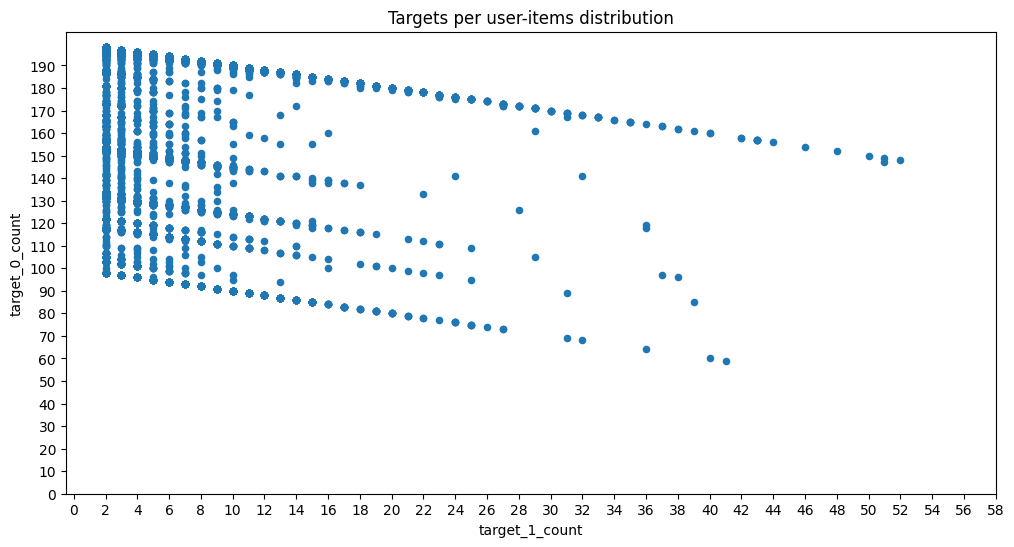

In [9]:
candidates_to_sample_targets_df.plot.scatter(x='target_1_count', y='target_0_count', xticks=range(0,60,2), yticks=range(0,200, 10), title='Targets per user-items distribution', figsize=(12,6))

#### Для каждого пользователя оставляем пропорцию примерно 25% положительных и 75% негативных примеров

In [10]:
candidates_to_sample_targets_df.reset_index(inplace=True)

In [11]:
def sample_target(group):
    stats_df = candidates_to_sample_targets_df.query(f'user_id == {group.user_id.iat[0]}')
    target_1_count = stats_df['target_1_count'].iat[0]
    target_0_count = stats_df['target_0_count'].iat[0]
    
    sample_0_max = target_1_count * 3
    sample_0_count = int(min(sample_0_max, target_0_count, group.shape[0]))
    return group.sample(sample_0_count)

In [12]:
candidates_to_sample_trunk = candidates_to_sample.query('target == 0').groupby('user_id').apply(lambda x: sample_target(x))
candidates_to_sample_trunk

user_id   item_id  score_als  score_genre  \
user_id                                                        
10      152640          10    373493   0.000000      0.64312   
        126481          10  21998692   0.061030      0.00000   
        179052          10    373494   0.000000      0.64312   
        126466          10  41035226   0.143629      0.00000   
        100496          10  43052381   0.193324      0.00000   
...                    ...       ...        ...          ...   
1374582 242372552  1374582  67538121   0.205704      0.00000   
        242389403  1374582  68938482   0.122635      0.00000   
        242389397  1374582  37641523   0.135271      0.00000   
        242406168  1374582  59735856   0.110438      0.00000   
        242422867  1374582  43716993   0.095608      0.00000   

                   track_popularity_count  genre_popularity_count  \
user_id                                                             
10      152640                        189                51464261   
        126481                      35942                17282553   
        179052                        114                51464261   
        126466                      30575                14975217   
        100496                      49794                51464261   
...                                   ...                     ...   
1374582 242372552                   30275                23365431   
        242389403                   37189                14975217   
        242389397                   34741                51464261   
        242406168                   16377                12456152   
        242422867                   42272                23365431   

                   user_track_count  target  
user_id                                      
10      152640                   29       0  
        126481                   29       0  
        179052                   29       0  
        126466                   29       0  
        100496                   29       0  
...                             ...     ...  
1374582 242372552               205       0  
        242389403               205       0  
        242389397               205       0  
        242406168               205       0  
        242422867               205       0  

[843151 rows x 8 columns]

Комментарий ревьюера ✔️
Разумно.

In [13]:
candidates_to_train = pd.concat([
    candidates_to_sample.query('target == 1'),
    candidates_to_sample_trunk
]).reset_index(drop=True).sort_values(by='user_id')

candidates_to_train

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,target
281160,10,21998692,0.061030,0.00000,35942,17282553,29,0
281159,10,373493,0.000000,0.64312,189,51464261,29,0
281164,10,40765450,0.055166,0.00000,9591,51464261,29,0
123,10,49125069,0.114226,0.00000,42845,51464261,29,1
281162,10,41035226,0.143629,0.00000,30575,14975217,29,0
...,...,...,...,...,...,...,...,...
1124304,1374582,35590676,0.100796,0.00000,11484,23365431,205,0
1124297,1374582,70619465,0.115451,0.00000,45522,51464261,205,0
1124296,1374582,51152139,0.096401,0.00000,9626,51464261,205,0
280998,1374582,79071657,0.160986,0.00000,30252,51464261,205,1


In [14]:
# посмотрим сколько таргетов теперь у пользователя

candidates_to_train_targets_df = candidates_to_train.groupby(by='user_id').apply(lambda group: calc_user_targets_info(group)) 
candidates_to_train_targets_df.sort_values(by='target_1_count', ascending=False)

,item_count,target_1_count,target_0_count
user_id,,,
604207,200,52,148
1174475,198,51,147
356544,200,51,149
387103,200,50,150
1285623,192,48,144
...,...,...,...
619000,8,2,6
619017,8,2,6
619030,8,2,6


<Axes: title={'center': 'Targets per user-items distribution'}, xlabel='target_1_count', ylabel='target_0_count'>

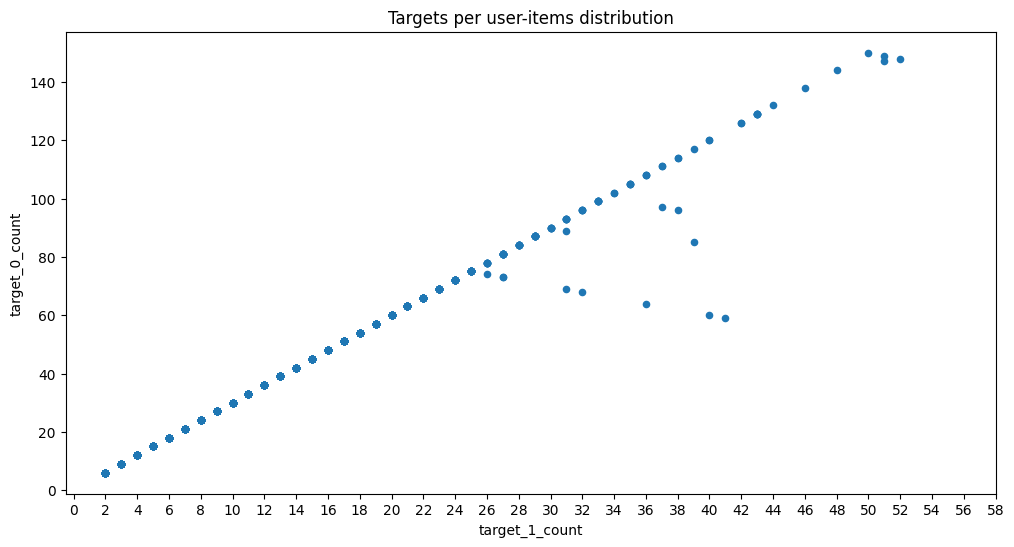

In [15]:
candidates_to_train_targets_df.plot.scatter(x='target_1_count', y='target_0_count', xticks=range(0,60,2), title='Targets per user-items distribution', figsize=(12,6))

Видим, что минимальный баланс 1/3 соблюден

#### Сохраним итоговый обучающий набор для модели ранжирования

In [191]:
import pandas as pd

path = 'data/recsys/'
candidates_to_train.to_parquet(path + 'candidates_to_train.parquet')

## Обучение ранжирующей модели
- будем применять catboost классификатор в качестве модели ранжирования
- TODO: для задачи ранжирования также рекомендуется использовать CatBoostRanker, который лучше оптимизирует метрику NDCG

In [14]:
import pandas as pd

path = 'data/recsys/'
candidates_to_train = pd.read_parquet(path + 'candidates_to_train.parquet')

In [193]:
candidates_to_train

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,target
281160,10,51447372,0.000000,0.70014,125,51464261,29,0
281159,10,373500,0.000000,0.64312,89,51464261,29,0
281164,10,35515789,0.126154,0.00000,23795,51464261,29,0
123,10,49125069,0.114226,0.00000,42845,51464261,29,1
281162,10,41832275,0.154456,0.00000,28578,14975217,29,0
...,...,...,...,...,...,...,...,...
1124304,1374582,41631554,0.153013,0.00000,15947,23365431,205,0
1124297,1374582,63083897,0.131248,0.00000,11049,2084052,205,0
1124296,1374582,68106316,0.094246,0.00000,12304,17282553,205,0
280998,1374582,79071657,0.160986,0.00000,30252,51464261,205,1


In [15]:
from catboost import CatBoostClassifier, Pool, CatBoostRanker

feature_cols = ['score_als', 'score_genre', 'track_popularity_count', 'genre_popularity_count',	'user_track_count']
X = candidates_to_train[feature_cols]
y = candidates_to_train['target']

n_iterations = 1000
learning_rate = 0.1
depth = 6
loss_function = 'Logloss'
verbose = 1000
random_seed = 91

model_cb = CatBoostClassifier(iterations=n_iterations, learning_rate=learning_rate, depth=depth, loss_function=loss_function, verbose=verbose, random_seed=random_seed)
model_cb.fit(X=X, y=y)

0:	learn: 0.5896041	total: 158ms	remaining: 2m 38s
999:	learn: 0.4014846	total: 1m 36s	remaining: 0us


### Оценка важности признаков

In [19]:
feature_importance = pd.DataFrame(
    model_cb.get_feature_importance(),
    index=feature_cols,
    columns=['feature_importance'])

feature_importance.sort_values(by='feature_importance', ascending=False)

,feature_importance
score_genre,49.270923
track_popularity_count,21.700821
genre_popularity_count,13.774317
score_als,9.434479
user_track_count,5.819459


Сохраним обученную модель в файл

In [199]:
path = 'data/recsys/'
model_cb.save_model(path + 'model_catboost_clsf.cbm')

Восстановление модели из файла

In [11]:
from catboost import CatBoostClassifier

path = 'data/recsys/'
model_cb = CatBoostClassifier().load_model(path + 'model_catboost_clsf.cbm')

## Формирование тестовых рекомендаций

In [1]:
# pandas
import pandas as pd

path = 'data/recsys/'
features = pd.read_parquet(path + 'features-final.parquet')

In [2]:
import pandas as pd
path = 'data/recsys/'

# events_test ранее сформирован в начале раздела 3
events_test = pd.read_parquet(path + "events_test.parquet", columns=['user_id', 'item_id', 'started_at'])

# разделяем тестовые и обучающие выборки для ранжирования
train_rank_split = '2022-12-23'
events_rank_test = events_test.query('started_at > @train_rank_split')

events_rank_test.shape

(5403167, 3)

In [4]:
# выберем кандидаты для ранжирования из тех пользователей, которые есть в тестовом датасете
candidates_to_rank = features[features['user_id'].isin(events_rank_test['user_id'])]
candidates_to_rank

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count
800,4,18820599,0.208646,0.0,43918,12267018,234
801,4,694683,0.191520,0.0,62521,2606577,234
802,4,647040,0.186123,0.0,42152,2606577,234
803,4,40493419,0.183279,0.0,29498,515103,234
804,4,986,0.180763,0.0,19272,12267018,234
...,...,...,...,...,...,...,...
242490135,1374582,48591588,0.095507,0.0,26233,23365431,205
242490136,1374582,33308971,0.095246,0.0,24818,743365,205
242490137,1374582,72340123,0.094276,0.0,7757,14975217,205
242490138,1374582,68106316,0.094246,0.0,12304,17282553,205


Комментарий ревьюера ⚠️
events_rank_test['user_id'] - это Series, для проверки вхождения используется хеширование, но при большом колтчестве записей это может быть медленно. Лучше преобразовать в set.

## Выполнение ранжирование - получение топ-100 предложений

In [7]:
feature_cols = ['score_als', 'score_genre', 'track_popularity_count', 'genre_popularity_count',	'user_track_count']
X = candidates_to_rank[feature_cols]

predictions = model_cb.predict_proba(X)
predictions

array([[0.7938804 , 0.2061196 ],
       [0.93008272, 0.06991728],
       [0.90014304, 0.09985696],
       ...,
       [0.56722339, 0.43277661],
       [0.60056968, 0.39943032],
       [0.6725439 , 0.3274561 ]])

In [8]:
candidates_to_rank['cb_clsf_score'] = predictions[:,1]
candidates_to_rank = candidates_to_rank.sort_values(by=['user_id', 'cb_clsf_score'], ascending=[True, False])
candidates_to_rank['rank'] = candidates_to_rank.groupby(by='user_id').cumcount()+1

candidates_to_rank

/tmp/ipykernel_6065/1229464139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates_to_rank['cb_clsf_score'] = predictions[:,1]


,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,cb_clsf_score,rank
818,4,38646012,0.132286,0.0,29377,29660560,234,0.690686,1
808,4,32851197,0.153471,0.0,35808,51464261,234,0.619599,2
842,4,60292250,0.100394,0.0,74461,3144302,234,0.613671,3
889,4,38903142,0.082427,0.0,15545,17282553,234,0.550437,4
813,4,24327639,0.136376,0.0,18776,2606577,234,0.498621,5
...,...,...,...,...,...,...,...,...,...
242490091,1374582,52395280,0.114465,0.0,39717,17282553,205,0.172292,96
242490136,1374582,33308971,0.095246,0.0,24818,743365,205,0.160815,97
242490068,1374582,9167465,0.140317,0.0,30774,12456152,205,0.149639,98
242490072,1374582,37641523,0.135271,0.0,34741,51464261,205,0.113866,99


Оставим не более топ-100 рекомендаций для пользователя

In [11]:
candidates_to_rank = candidates_to_rank[candidates_to_rank['rank'] <= 100]
candidates_to_rank

,user_id,item_id,score_als,score_genre,track_popularity_count,genre_popularity_count,user_track_count,cb_clsf_score,rank
818,4,38646012,0.132286,0.0,29377,29660560,234,0.690686,1
808,4,32851197,0.153471,0.0,35808,51464261,234,0.619599,2
842,4,60292250,0.100394,0.0,74461,3144302,234,0.613671,3
889,4,38903142,0.082427,0.0,15545,17282553,234,0.550437,4
813,4,24327639,0.136376,0.0,18776,2606577,234,0.498621,5
...,...,...,...,...,...,...,...,...,...
242490091,1374582,52395280,0.114465,0.0,39717,17282553,205,0.172292,96
242490136,1374582,33308971,0.095246,0.0,24818,743365,205,0.160815,97
242490068,1374582,9167465,0.140317,0.0,30774,12456152,205,0.149639,98
242490072,1374582,37641523,0.135271,0.0,34741,51464261,205,0.113866,99


## Сохраним результат ранжирования в файл

In [12]:
path = 'data/recsys/'
candidates_to_rank.to_parquet(path + 'recommendations.parquet')

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

### Загрузка данных 

In [4]:
import pandas as pd

path = 'data/recsys/'

#items = pd.read_parquet(path + "items.parquet", columns=['item_id', 'track_name'])

events_train = pd.read_parquet(path + "events_train.parquet", columns=['user_id', 'item_id', 'started_at'])


In [32]:
import pandas as pd

path = 'data/recsys/'

items = pd.read_parquet(path + "items.parquet", columns=['item_id', 'track_name'])

events_train = pd.read_parquet(path + "events_train.parquet", columns=['user_id', 'item_id', 'started_at'])
events_test = pd.read_parquet(path + "events_test.parquet", columns=['user_id', 'item_id', 'started_at'])

train_rank_split = '2022-12-23'
events_rank_train = events_test.query('started_at <= @train_rank_split')
events_rank_test = events_test.query('started_at > @train_rank_split')

events_train_big = pd.concat([events_train, events_rank_train])

# проверим, что все объекты на которых было выполнено ранжирование были в обучающем наборе - исключим самые свежие объекты при их наличии, так как по ним заведомо не может быть сформировано рекомендаций
events_rank_test = events_rank_test[events_rank_test["item_id"].isin(events_train_big["item_id"])]

### Функция расчета матрицы ошибок

- формирует данные для матрицы ошибок (confusion matrix)
    - TP, FP, TN, FN

In [7]:
def calc_confusine_matrix(events_rank_test, recommendations, top_k = 100):
    
    # gt - "позитивные" объекты - явное наличие объекта в истории взаимодействия
    events_rank_test['gt'] = True

    # top_k
    recs = recommendations.groupby('user_id').head(top_k)

    cm = events_rank_test[['user_id', 'item_id', 'gt']].merge(
        recs[['user_id', 'item_id', 'rank_score']],
        on=['user_id', 'item_id'],
        how='outer'
    )

    # заполним пустоты, что равнозначно отрицательному значению - т.к. не попал в merge
    cm['gt'] = cm['gt'].fillna(False)

    # pr - наличие рекомендаций по данному объекту
    cm['pr'] = ~cm['rank_score'].isna()
    # tp - верное попадение
    cm['tp'] = cm['gt'] & cm['pr']
    # fp - неверное попадение
    cm['fp'] = ~cm['gt'] & cm['pr']
    # fn - неверное исключение
    cm['fn'] = cm['gt'] & ~cm['pr']

    return cm

Комментарий ревьюера ✔️
Выделил логику построения матрицы ошибок и вычисления precision/recall в отдельные функции.

### Функция расчета метрик precision, recall

In [8]:
def calc_metrix(cm):
    cm_grouper = cm.groupby('user_id')

    # precision = tp/(tp + fp)
    precision = cm_grouper['tp'].sum() / (cm_grouper['tp'].sum() + cm_grouper['fp'].sum())
    precision = precision.fillna(0).mean()

    # recall = tp/(tp + fn)
    recall = cm_grouper['tp'].sum() / (cm_grouper['tp'].sum() + cm_grouper['fn'].sum())
    recall = recall.fillna(0).mean()

    return precision, recall

### Оценка финальных рекомендаций (recommendations)

#### Precision, recall

In [1]:
import pandas as pd

path = 'data/recsys/'
recommendations = pd.read_parquet(path + 'recommendations.parquet', columns=['user_id', 'item_id', 'cb_clsf_score'])
recommendations.rename(columns={'cb_clsf_score': 'rank_score'}, inplace=True)

In [3]:
cm = calc_confusine_matrix(events_rank_test, recommendations)
cm

,user_id,item_id,gt,rank_score,pr,tp,fp,fn
0,4,86836928,True,NaN,False,False,False,True
1,4,87446393,True,NaN,False,False,False,True
2,4,91718971,True,NaN,False,False,False,True
3,4,92133060,True,NaN,False,False,False,True
4,4,94227416,True,NaN,False,False,False,True
...,...,...,...,...,...,...,...,...
58943604,1374582,52395280,False,0.172292,True,False,True,False
58943605,1374582,33308971,False,0.160815,True,False,True,False
58943606,1374582,9167465,False,0.149639,True,False,True,False
58943607,1374582,37641523,False,0.113866,True,False,True,False


In [5]:
precision, recall = calc_metrix(cm)

print(f'precision = {100*precision:.2f}%, recall = {100*recall:.2f}%')

precision = 0.23%, recall = 6.65%


Метрики для топ-100: 
- precision = 0.23%
- recall = 6.65%

In [ ]:
# посмотрим на метрики для топ-5 для интереса

top_k = 5
cm = calc_confusine_matrix(events_rank_test, recommendations, top_k)
precision, recall = calc_metrix(cm)

print(f'top-{top_k}: precision = {100*precision:.2f}%, recall = {100*recall:.2f}%')

top-5: precision = 0.99%, recall = 1.30%


Метрики для топ-5: 
- precision = 0.99%
- recall = 1.30%

#### Покрытие (coverage)

In [3]:
coverage = recommendations['item_id'].nunique() / items['item_id'].nunique()
print(f'coverage = {100*coverage:.2f}%')

coverage = 1.11%


coverage = 1.11%

#### Новизна (novelty)

In [ ]:
events_train['seen'] = True
events_train.drop(columns='started_at', inplace=True)
events_train

In [6]:
recommendations = recommendations.merge(
    events_train,
    on=['user_id', 'item_id'],
    how='left')

recommendations['seen'] = recommendations['seen'].fillna(False).astype('bool')

In [7]:
novelty_user = 1-recommendations.groupby('user_id')['seen'].mean()
novelty = novelty_user.mean()

print(f'novelty = {100*novelty:.2f}%')

novelty = 83.36%


novelty = 83.36%

### Оценка топ популярных рекомендаций (top-popular)

In [1]:
import pandas as pd

path = 'data/recsys/'
top_popular = pd.read_parquet(path + 'top_popular.parquet')
top_popular = top_popular.reset_index()

#### Precision, recall

Немного адаптируем расчет матрицы ошибок, т.к. топ-популярных рекомендаций - это обезличенные рекомендации (нет пользователя)

In [14]:
def calc_confusine_matrix_for_pop(events_rank_test, recommendations, top_k = 100):
    
    # gt - "позитивные" объекты - явное наличие объекта в истории взаимодействия
    events_rank_test['gt'] = True

    # top_k
    recs = recommendations.head(top_k)

    cm = events_rank_test[['user_id', 'item_id', 'gt']].merge(
        recs[['item_id', 'count']],
        on=['item_id'],
        how='outer'
    )

    # заполним пустоты, что равнозначно отрицательному значению - т.к. не попал в merge
    cm['gt'] = cm['gt'].fillna(False)

    # pr - наличие рекомендаций по данному объекту
    cm['pr'] = ~cm['count'].isna()
    # tp - верное попадение
    cm['tp'] = cm['gt'] & cm['pr']
    # fp - неверное попадение
    cm['fp'] = ~cm['gt'] & cm['pr']
    # fn - неверное исключение
    cm['fn'] = cm['gt'] & ~cm['pr']

    return cm

In [17]:
top_k = 100
cm = calc_confusine_matrix_for_pop(events_rank_test, top_popular)
cm

,user_id,item_id,gt,count,pr,tp,fp,fn
0,4,86836928,True,NaN,False,False,False,True
1,11,86836928,True,NaN,False,False,False,True
2,4696,86836928,True,NaN,False,False,False,True
3,6922,86836928,True,NaN,False,False,False,True
4,21409,86836928,True,NaN,False,False,False,True
...,...,...,...,...,...,...,...,...
5402992,1374495,39033911,True,NaN,False,False,False,True
5402993,1374495,73658977,True,NaN,False,False,False,True
5402994,1374509,89814905,True,NaN,False,False,False,True
5402995,1374546,73909423,True,NaN,False,False,False,True


In [18]:
precision, recall = calc_metrix(cm)

print(f'top-{top_k}: precision = {100*precision:.2f}%, recall = {100*recall:.2f}%')

top-100: precision = 13.94%, recall = 3.21%


Результат для топ-популярных
- top-100: precision = 13.94%, recall = 3.21%

In [20]:
top_k = 5
cm = calc_confusine_matrix_for_pop(events_rank_test, top_popular, top_k)
precision, recall = calc_metrix(cm)

print(f'top-{top_k}: precision = {100*precision:.2f}%, recall = {100*recall:.2f}%')

top-5: precision = 0.81%, recall = 0.12%


- top-5: precision = 0.81%, recall = 0.12%

#### Покрытие (coverage)

In [4]:
coverage = top_popular['item_id'].nunique() / items['item_id'].nunique()

print(f'coverage = {100*coverage:.2f}%')

coverage = 0.01%


coverage = 0.01% (оно и понятно, так как это топ-100 треков от общего почти ~ 932 тыс.)

#### Новизна (novelty)

In [ ]:
events_train.drop(columns=['started_at'], inplace=True)

In [11]:
top_popular['pop'] = True

event_top_popular = events_train.merge(
    top_popular,
    on=['item_id'],
    how='left')

event_top_popular['pop'] = event_top_popular['pop'].fillna(False).astype('bool')


In [14]:
novelty_user = 1-event_top_popular.groupby('user_id')['pop'].mean()
novelty = novelty_user.mean()

print(f'novelty = {100*novelty:.2f}%')

novelty = 94.78%


novelty = 94.78% - то есть 95 треков из 100 не были ранее прослушаны

### Оценка персональных рекомендаций (полученных при помощи ALS)

In [2]:
import pandas as pd

path = 'data/recsys/'
als_recommendations = pd.read_parquet(path + "personal_als.parquet").astype({'score': 'float32'})
als_recommendations.rename(columns={'score': 'rank_score'}, inplace=True)

#### Precision, recall

In [9]:
cm = calc_confusine_matrix(events_rank_test, als_recommendations)
precision, recall = calc_metrix(cm)

print(f'precision = {100*precision:.2f}%, recall = {100*recall:.2f}%')

precision = 0.09%, recall = 2.75%


Для Топ-100 
- precision = 0.09%
- recall = 2.75%

In [10]:
top_k = 5
cm = calc_confusine_matrix(events_rank_test, als_recommendations, top_k)
precision, recall = calc_metrix(cm)

print(f'top-{top_k} - precision = {100*precision:.2f}%, recall = {100*recall:.2f}%')

top-5 - precision = 0.09%, recall = 0.17%


Для Топ-5
- precision = 0.09%
- recall = 0.17%

#### Покрытие (coverage)

In [30]:
coverage = als_recommendations['item_id'].nunique() / items['item_id'].nunique()
print(f"{100*coverage:.2f}%")

1.07%


Сoverage = 1.07% (на всех топ-100 рекомендаций)

#### Новизна (novelty)

In [ ]:
events_train['seen'] = True
events_train.drop(columns='started_at', inplace=True)
events_train

In [ ]:
als_recommendations = als_recommendations.merge(
    events_train,
    on=['user_id', 'item_id'],
    how='left')

als_recommendations['seen'] = als_recommendations['seen'].fillna(False).astype('bool')


In [12]:
novelty_user = 1-als_recommendations.groupby('user_id')['seen'].mean()
novelty = novelty_user.mean()

print(f'novelty = {100*novelty:.2f}%')

novelty = 83.86%


novelty = 83.86% (для всех топ-100 рекомендаций)

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

## Полученные метрики
- топ-популярных (топ-100)
    - top-100                   - top-5 
        - precision = 13.94%        - precision = 0.81%
        - recall = 3.21%            - recall = 0.12%
        - coverage = 0.01%
        - novelty = 94.78%
- персональные als-рекомендации
    - top-100                   - top-5
        - precision = 0.09%         - precision = 0.09% 
        - recall = 2.75%            - recall = 0.17% 		
        - coverage = 1.07%
        - novelty = 83.86%
- финальные рекомендации
    - top-100                   - top-5 
        - precision = 0.23%         - precision = 0.99%
        - recall = 6.65%            - recall = 1.30%    
        - coverage = 1.11%
        - novelty = 83.36%
## Выводы
- топ-популярных показали лучшую точность (13,94%), что может говорить о том, что люди выбирали 14 самых популярных предложений из 100
    - одновременно у топ-популярных самая высока новизна (94,78%) - то есть 95 треков из 100 являются новыми для пользователя
- финальные рекомендации имеют самую высокую полноту - 6.65% - что может говорить о том, что пользователя чаще выбирает именно эти предложения
- общий вывод - сочетание различных признаков и ранжирование позволили увеличить полноту, что означает учет больших интересов пользователей, но и добавляет много того, что пользователю неинтересно
					

						


Комментарий ревьюера ✔️
Ты начал с тщательной очистки данных, провел подробный анализ и в итоге построил гибридную рекомендательную систему, объединив ALS, контентные признаки и ранжирование CatBoost. Когда столкнулся с нехваткой памяти, оперативно переключился на Polars и FAISS, правильно настроил индексы и добился приемлемой скорости расчета. Также молодец, что сравнил три подхода к рекомендациям и оценил их не только по точности и полноте, но и по покрытию и новизне.

В следующих работах рекомендую стараться больше документировать свои решения, добавить логирование ключевых этапов и простые тесты для функций очистки и расчета метрик, избегать дублирования кода и всегда делать .copy() перед изменением срезов DataFrame, чтобы не нарваться на предупреждения. В целом работа выполнена на высоком уровне, дальше можно развиваться в сторону автоматизации пайплайна и мониторинга качества рекомендаций в реальном времени.